# Deep Learning
## Summative assessment
### Coursework 2

#### Instructions

This coursework is released on **Tuesday 11th March 9.00** and is due by **Tuesday 1st April 9.00**. It is worth **50%** of your overall mark. There are 4 questions in this assessment, and a total of 50 marks are available. **You should attempt to answer all questions.** In addition to the total number of marks shown per question below, an additional 5 marks is available for presentation and clarity/quality of code.

This assessment assesses your ability to implement and analyse modifications to the variational autoencoder (VAE) algorithm. In particular, you will explore techniques for improving the posterior approximation and improving estimates of the model evidence.

You can make imports as and when you need them throughout the notebook, and add code cells where necessary. Make sure your notebook executes correctly in sequence before submitting.

#### Submission instructions

The submission for this assessment will consist of a notebook (.ipynb file) and PDF report.

Ensure your notebook executes correctly in order. Save your notebook .ipynb file **after you have executed it** (so that outputs are all showing). It is recommended to also submit a PDF/HTML copy of your executed notebook, in case the .ipynb file is corrupted for some reason.

Upload a zip file containing your notebook and separate PDF/HTML file(s) by the deadline above.

This assignment must be attempted individually; your submission must be your own, unaided work. Candidates are prohibited from discussing assessed coursework, and must abide by [Imperial College’s rules](https://www.imperial.ac.uk/media/imperial-college/administration-and-support-services/registry/academic-governance/public/academic-policy/academic-integrity/Examination-and-assessments---academic-integrity.pdf) regarding academic integrity and plagiarism. Unless specifically authorised within the assignment instructions, the submission of output from [generative AI tools](https://www.imperial.ac.uk/about/leadership-and-strategy/provost/vice-provost-education/generative-ai-tools-guidance/) (e.g., ChatGPT) for assessed coursework is prohibited. Violations will be treated as an examination offence. Enabling other candidates to plagiarise your work constitutes an examination offence. To ensure quality assurance is maintained, departments may choose to invite a random selection of students to an ‘authenticity interview’ on their submitted assessments.

In [1]:
# You will need the following imports for this assessment. You can make additional imports when you need them
import os

os.environ['KERAS_BACKEND'] = 'torch'

import warnings
warnings.filterwarnings('ignore')
import keras
from keras import ops
import numpy as np
import matplotlib.pyplot as plt

from keras.api.models import Sequential, Model
from keras.api.layers import Input, Dense

#### Binarized MNIST Dataset

This assessment makes use of a specific binarization of the MNIST images. This dataset is frequently used to evaluate generative models of images, so labels are not provided.

The dataset was first introduced in the following paper:

* Salakhutdinov, R. and Murray, I. (2008), "On the quantitative analysis of deep belief networks", in *Proceedings of the 25th international conference on Machine learning*, 892-879.

This dataset is available from the [TensorFlow Datasets](https://www.tensorflow.org/datasets) library in prepared train/validation/test splits, and can be loaded into TF Dataset objects by running the following cell.

In [2]:
# Load a binarised version of MNIST

import tensorflow_datasets as tfds

train_ds, val_ds, test_ds = tfds.load('binarized_mnist', data_dir='data', split=['train', 'validation', 'test'])
print(train_ds)
print(train_ds.element_spec)

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None)}>
{'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None)}


2025-04-21 16:26:48.611689: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-04-21 16:26:48.611732: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-04-21 16:26:48.611736: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-04-21 16:26:48.611777: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-21 16:26:48.611787: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### Variational autoencoder

Your task in this assessment is to experiment with and analyse variants of the variational autoencoder algorithm. This will involve modifications to the objective function and the variational posterior.

Throughout this assessment you should use Keras model subclassing and the high level `compile` and `fit` APIs to train your model using the VAE algorithm. The following base `VAE` class is provided for you (taken from the week 9 lecture notes). In the following questions you should subclass from this base class where possible, in order to reduce repeated code. You are free to override the provided methods as needed.

In [3]:
from keras.api.metrics import Mean
import tensorflow as tf
import torch


class VAE(Model):

    def __init__(self, encoder, decoder, num_mc_samples=1, **kwargs):
        """
        You should override this method as necessary in your implementations.
        """
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_metric = Mean(name='loss')
        self.nll_metric = Mean(name='nll')
        self.kl_metric = Mean(name='kl')
        self.pi = ops.array(np.pi)
        self.L = num_mc_samples

    def compute_losses(self, data):
        """
        This method should compute and return the loss, kl_loss and nll_loss.
        You should override this method as necessary in your implementations.
        """
        z_mean, z_log_var = self.encoder(data)
        kl_loss = 0.5 * ops.sum((ops.square(z_mean) + ops.exp(z_log_var) - 1 - z_log_var), axis=-1)
        kl_loss = ops.mean(kl_loss)

        epsilon = keras.random.normal(ops.shape(z_mean))
        z_std = ops.exp(0.5 * z_log_var)
        z_sample = z_mean + (z_std * epsilon)

        x_mean, x_log_std = self.decoder(z_sample)
        log_Z = 0.5 * ops.log(2 * self.pi)
        nll_loss = 0.5 * ops.square((data - x_mean) / ops.exp(x_log_std)) + x_log_std + log_Z
        nll_loss = ops.mean(ops.sum(nll_loss, axis=[-1, -2]))

        loss = kl_loss + nll_loss
        return loss, kl_loss, nll_loss

    def call(self, inputs):
        """
        This method should compute the approximate posterior using the encoder,
        and draw a single sample to pass through the decoder.
        You should override this method as necessary in your implementations.
        """
        z_mean, z_log_var = self.encoder(inputs)
        epsilon = keras.random.normal(ops.shape(z_mean))
        z_std = ops.exp(0.5 * z_log_var)
        z_sample = z_mean + (z_std * epsilon)
        return self.decoder(z_sample)

    def train_step(self, data):
        if keras.config.backend() == 'tensorflow':
            with tf.GradientTape() as tape:
                loss, kl_loss, nll_loss = self.compute_losses(data)
                loss = ops.mean(loss)
            grads = tape.gradient(loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        else:
            assert keras.config.backend() == 'torch'
            self.zero_grad()
            loss, kl_loss, nll_loss = self.compute_losses(data)
            loss = ops.mean(loss)

            loss.backward()

            gradients = [v.value.grad for v in self.trainable_weights]
            with torch.no_grad():
                self.optimizer.apply(gradients, self.trainable_weights)

        self.loss_metric.update_state(loss)
        self.nll_metric.update_state(nll_loss)
        self.kl_metric.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        loss, kl_loss, nll_loss = self.compute_losses(data)
        loss = ops.mean(loss)
        self.loss_metric.update_state(loss)
        self.nll_metric.update_state(nll_loss)
        self.kl_metric.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    @property
    def metrics(self):
        return [self.loss_metric, self.nll_metric, self.kl_metric]

### Question 1 (Total 12 marks)

a) Using the `train_ds`, `val_ds` and `test_ds` objects returned above, prepare your Datasets ready for training and evaluating your model that will be trained using the VAE algorithm. Each Dataset should return a single Tensor consisting of a batch of binarised MNIST images.

**(2 marks)**

In [4]:
def prepare_dataset(ds, batch_size: int = 64, shuffle: bool = False):
    '''
    Prepare the dataset `ds` for training or evaluation.
    Args:
        ds: A tensorflow PrefetchDataset
        batch_size: The batch size to partition the dataset into
        shuffle: If True, the dataset is shuffled

    Returns: Tensorflow DataSet
    '''
    ds = ds.map(lambda x: tf.cast(x['image'], 'float32'))  # originally tf.uint8
    if shuffle:
        ds = ds.shuffle(buffer_size=len(ds))
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def get_datasets(batch_size: int = 64):
    '''
    Load and preprocess the MNIST dataset(s)
    Args:
        batch_size: The batch size

    Returns: Tensorflow dataset or tuple of Tensorflow datasets
    '''
    train, val, test = tfds.load('binarized_mnist', data_dir='data', split=['train', 'validation', 'test'])
    train = prepare_dataset(train, batch_size=batch_size, shuffle=True)
    val = prepare_dataset(val, batch_size=batch_size, shuffle=False)
    test = prepare_dataset(test, batch_size=batch_size, shuffle=False)
    return train, val, test

In [5]:
train, val, test = get_datasets()
print(len(train))
print(len(val))
print(len(test))
print(type(train))
data = next(iter(train.take(1)))
print(data.shape)
print(data.dtype)


782
157
157
<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(64, 28, 28, 1)
<dtype: 'float32'>


b) Implement the VAE algorithm to learn a generative model of the binarized MNIST dataset. In particular, you should define encoder and decoder networks, and write a `VAEDiagonal` class that implements the training update and evaluation steps using the ELBO $\mathcal{L}_{VAE}(\theta, \phi; {x})$ as the objective function that we wish to maximise:

$$
\mathcal{L}_{VAE}(\theta, \phi; {x}) :=
 \mathbb{E}_{z\sim q_\phi({z}\mid {x})} \left[ \log p_\theta({x}, {z}) - \log q_\phi({z}\mid {x}) \right] \le \log p_\theta(x).
$$

Your implementation should follow the specifications:

* The `VAEDiagonal` class should subclass from the `VAE` class above
* The encoder network should use a fully factorised (diagonal) Gaussian for the approximate posterior $q_\phi(z \mid x)$
* The latent space should have dimension 2
* Your implementation should be entirely using Keras
* The ELBO objective should be approximated using the second form of the SGVB estimator:
$$
\hat{\mathcal{L}}^B(\theta,\phi;x)[q_\phi] := \frac{1}{L} \sum_{j=1}^L \log p_\theta(x\mid z^{(j)}) − D_{KL}(q_\phi(z\mid x) || p_\theta(z)),
$$
  * You should set $L=1$ in the model that you train (use a single Monte Carlo sample)
* The likelihood distribution $p_\theta(x\mid z^{(j)})$ should be chosen appropriately for the binary data
* Train your model using the high-level Keras API, and evaluate your trained model on the test set, clearly displaying the loss obtained on the test set.

You should aim to obtain final trained encoder and decoder networks that achieve an ELBO of at least -150 on the test set

_Make sure to save your model as it will be used again in later questions._

**(4 marks)**

### Solution

For a fully factorised Gaussian posterior $q_\phi(z \mid x)$, we have that

$$
q_\phi(z \mid x) = \prod_{i=1}^2 \mathcal{N}(z_i \mid \mu_i, \sigma_i^2)
$$

where $\mu_i$ and $\sigma_i^2$ are the mean and variance of the $i$th dimension of the latent space. The KL divergence term in the ELBO is given by



\begin{align}
D_{KL}(q_\phi(z\mid x) || p_\theta(z)) = \frac{1}{2}\left[ \mu_q^T\mu_q + \sum_{i=1}^l (\sigma_q)_i - l - \log \prod_{i=1}^l (\sigma_q)_i \right], \tag{1}
\end{align}

where $p_\theta(z) = \mathcal{N}(0, I)$ is the standard Gaussian prior, so $\mu_{0,i} = 0$ and $\sigma_{0,i}^2 = 1$.

The likelihood term in the ELBO corresponds to the reconstruction term $\log p_\theta(x \mid z)$ and must be chosen according to the type of observed data. Since we are using the binarized MNIST dataset, the pixel values are either 0 or 1, which suggests a Bernoulli likelihood is appropriate.
In this case, we assume that the likelihood $p_\theta(x \mid z)$ is modeled as a product of independent Bernoulli distributions:


$$
p_\theta(x \mid z) = \prod_{i=1}^D \text{Bernoulli}(x_i \mid \hat{x}_i)
$$

where $\hat{x}_i$ is the output of the decoder network for pixel $i$ after applying a sigmoid activation to ensure $\hat{x}_i \in (0,1)$.

This leads to the binary cross-entropy loss:

$$
\log p_\theta(x | z) = \text{BCE}(x, \hat{x}) = -\frac{1}{D} \sum_{i=1}^D \left( x_i \log(\hat{x}_i) + (1 - x_i) \log(1 - \hat{x}_i) \right) \tag{2}
$$

Here, $\hat{x}$ is obtained by decoding the sampled latent variable $z \sim q_\phi(z \mid x)$ through a decoder neural network with a final sigmoid activation.

Then, the ELBO becomes:

$$
\mathcal{L}(\theta, \phi; x) \approx -\text{BCE}(x, \hat{x}) - D_{KL}(q_\phi(z \mid x) \,\|\, p_\theta(z)) \tag{3}
$$
where $\text{BCE}(x, \hat{x})$ is given by (2). The KL divergence term is given by (1).

Note that (3) is the ELBO computed for a single sample image. In practice, one averages over multiple samples in the batch (in addition to the Monte Carlo samples).

### Comments on the implementation `VAEDiagonal` class

Using `tensorflow` as the backend resulted in instabilities that made it impossible to train the model on an Apple Silicon M1 Max chip. This issue was not present when training with `torch` as the backend or if we set the argument `run_eagerly = False` when compiling the model. It appears that the issue is to do with the M1 Max architecture and how it handles the `tensorflow` DAG. `run_eagerly = True` forces the graph to be evaluated at each step which makes the training very slow but it resolves the instabilities. The issue is not reproducible when training on Coursera either.

Prior to understanding the root cause of the issue, we made numerous attempts to resolve the numerical instabilities. Part of this effort was to implement the BCE loss function from scratch, instead of using the `keras` implementation, and manually clip anything that was passed into a log or exponential.
We also introduces an instance property that specifies whether the decoder outputs probabilities or logits.


In [6]:
class VAEDiagonal(VAE):

    def __init__(self, encoder, decoder, num_mc_samples=1, from_logits: bool = False, **kwargs):
        """
        You should override this method as necessary in your implementations.
        """
        super().__init__(encoder=encoder, decoder=decoder, num_mc_samples=num_mc_samples, **kwargs)
        self.from_logits = from_logits

    def _sample_z(self, z_mean, z_log_var):
        '''
        Sample z using the mean and standard deviation output from the decoder and Gaussian
        noise epsilon ~ N(0, 1) (l dimensional)

            z = mu_q + std_q * epsilon
        Args:
            z_mean: The mean of z, obtained using the encoder
            z_log_var: The log variance of z, obtained using the decoder

        Returns: An (L, l) tensor, where l is the dimension of the latent space and
        L is the number of Monte Carlo samples required
        '''
        batch_size, latent_dim = ops.shape(z_mean)

        # Sample epsilon ~ N(0, 1)
        epsilon = keras.random.normal(shape=(self.L, batch_size, latent_dim))

        # Reparameterisation trick
        z_std = ops.exp(0.5 * z_log_var)
        z_samples = z_mean + z_std * epsilon  # shape: (L, B, l)

        return z_samples

    def compute_losses(self, data):
        '''
        Compute the losses. The KL Loss term is the same as the VAE implementation but
        the reconstruction loss will now be the log likelihood of the Bernoulli distribution

        As with the base class, the encoder outputs the mean and log variance of z.
        The decoder outputs the probability $p$ of the Bernoulli distribution
        Args:
            data: a minibatch of the data

        Returns: the total loss, KL loss and negative log-likelihood loss (scalars)
        '''
        eps = 1e-7  # const used for numerical stability (logs)

        # Encode the data -> image shape to latent dim
        z_mean, z_log_var = self.encoder(data)  # (batch, latent_dim)
        batch_size, latent_dim = ops.shape(z_mean)

        # KL divergence term (analytical)
        kl_per_sample = 0.5 * ops.sum(
            ops.square(z_mean) + ops.exp(z_log_var) - 1 - z_log_var,
            axis=-1  # sum over latent dim
        )
        kl_loss = ops.mean(kl_per_sample)  # scalar

        # Sample z \sim q(z|x)
        z_samples = self._sample_z(z_mean, z_log_var)  # (MC samples, batch, latent_dim)
        z_samples = ops.reshape(z_samples, (self.L * batch_size, latent_dim))  # (MC Samples * batch, latent_dim)

        # Decode: returns logits or probabilities
        x_pred = self.decoder(z_samples)  # (MC samples * batch, H, W, C)
        _, H, W, C = ops.shape(data)

        # Expand ground truth to match shape
        x_true = ops.expand_dims(data, axis=0)  # (1, batch, H, W, C)
        x_true = ops.repeat(x_true, self.L, axis=0)  # (MC samples, batch, H, W, C)
        x_true = ops.reshape(x_true, ops.shape(x_pred))

        if self.from_logits:
            # --- BCE Loss ---
            # Use Keras' numerically stable BCE (handles logits internally)
            bce_per_pixel = keras.losses.binary_crossentropy(
                y_true=x_true,
                y_pred=x_pred,
                from_logits=True
            )  # shape: (L * B, H, W)
            # Sum over pixel dims (H, W) -> total BCE per image
            bce_per_image = ops.sum(bce_per_pixel, axis=[-1, -2])  # shape: (L * B,)

        else:
            # Clip probs to avoid log(0)
            x_pred = ops.clip(x_pred, eps, 1. - eps)

            # COMPUTE BCE Explicitly (using binary cross entropy loss from keras was leading to instabilities on M1 Max with Tensorflow
            bce_per_pixel = -(
                x_true * ops.log(x_pred) +
                (1. - x_true) * ops.log(1. - x_pred)
            )  # shape: (MC samples * batch, H, W, C)

            # Sum over pixel dimensions (H, W, C) -> total BCE per image
            bce_per_image = ops.sum(bce_per_pixel, axis=[-1, -2, -3])  # shape: (MC samples, batch)

        # Average over MC and batch
        nll_loss = ops.mean(bce_per_image)
        total_loss = kl_loss + nll_loss

        return total_loss, kl_loss, nll_loss


### Comments on the Encoder and Decoder Architecture

Below we present a final subset of models we tried. These models we developed progressively, starting from the simplest architecture which consists of 2 fully connected layers with appropriately chosen units for the encoder and decoder, and evolving to our final architecture which consists of multiple convolutional layers and fully connected layers.

**General Comments**

* There is a total of 9 architectures with the encoder-decoder pairs obtained using a `get_encoder_v#` and `get_decoder_v#` functions.
* All decoders output probabilities and not logits. During our experiments we tested the stability of the training for both options and did no find there was a noticeable difference.
* Almost all our models use have a kernel initialiser (He Uniform for layers with ReLU activation and GlorotNormal for layers with Sigmoid activation) and a kernel regulariser (L2). We found this helped the training convergence although the initial motivation was our attempt to resolve issues with `tensorflow` instabilities.
* The encoder and decoder architectures for each model are symmetric, as is customary practice when training VAE for image data.


**Model Evolution**

We began by training architectures consisting of only fully connected layers. Our first model has one 2 layers, a hidden one with 256 units and the output one whose size is determine by the problem, namely $28\times28$ for the decoder and $2\times2$ for the encoder, corresponding to the mean and log-variance vectors for the latent distribution.
This model already achieved an ELBO of -154.5 on the test data.
Adding two additional hidden layers significantly improved the model performance, resulting in an ELBO of -145.0 on the test data.

Next we experimented with architectures consisting of Convolutional layers for the encoder and Transpose Convolutional layers for the decoder, as is customary for image data.
The encoder for our benchmark model for this architecture (v2) consisted of 2 convolutional layers with 32 and 64 channels respectively, each of which downsampled the spatial dimensions through a stride of size 2.
The output layer of the encoder was a fully connected layer that reduced the units to 4, for the 2d mean and log variance of the latent distrivtuion.
The decoder reversed this architecture through the use of transpose convolutions with the same stride for the upsampling.
The performance of this model similar to our first model with just two fully connected layers.
We tried also to use stride size equal to 1 and max pooling for the downsampling in the encoder, and stride size equal to 1 and upsampling for the decoder but found that it performed significantly worse. Similarly, reducing the kernel size to $2 \times 2$ had the same effect so we chose $3 \times 3$ for the subsequent experiments.

The rest of our experiments involved stacking more convolutional layers, further increasing the channels, prior to passing the flattened output through a series of fully connected layers (encoder architectures).
We found that if we increased the depth of the neural network too much, the model stopped training, even if we introduced multiple layers of batch normalisation and drop out (appropriately placed; batch normalisation layers were placed after the convolutional layers, and before the activation and drop out layers were placed after fully connected layers).

Our final model, which achieved an ELBO of -136.1 on the test data, is a moderately deep encoder and decoder. The encoder stacks two stride-2 convolutional layers (32 and 64 filters) with batch normalization and ReLU activations to compress spatial dimensions. This is followed by a fully connected block with three dense layers that reduce the units to 512, 256 and 128 respectively, culminating in a final dense layer outputting the mean and log-variance vectors for the latent distribution. The decoder reverses this process, beginning with a dense expansion into a $7 \times 7 \times 64$ feature map, then applying two transposed convolutions with batch normalization and ReLU activations (except the final sigmoid). Regularization is consistently applied via kernel regularizers, and all layers are initialized with custom initializers tuned for ReLU or sigmoid activations, optimizing convergence. The architecture balances expressive capacity with stable variational inference through normalization, careful dimensional transitions, and deep feedforward structure on both sides.

In [7]:
# Define the encoder-decoder pairs
import keras.src.layers
from keras import ops
from keras.api.models import Model
from keras.api.layers import (Input, Dense, Reshape, Flatten, Conv2D, MaxPool2D, Conv2DTranspose, BatchNormalization,
                              ReLU, UpSampling2D)
from typing import Tuple

REGULARIZER = keras.regularizers.L2()
INITIALIZER_RELU = keras.initializers.HeUniform()
INITIALIZER_SIGMOID = keras.initializers.GlorotNormal()


def get_decoder_v0(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(latent_dim,))
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(img_h * img_w * img_c, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_SIGMOID,
              activation='sigmoid')(h)
    outputs = Reshape((img_h, img_w, img_c))(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v0(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(img_h, img_w, img_c))
    h = Flatten()(inputs)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)

    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v1(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(latent_dim,))
    h = Dense(64, activation='leaky_relu', kernel_regularizer=REGULARIZER,
              kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(128, activation='leaky_relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(256, activation='leaky_relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(img_h * img_w * img_c, activation='sigmoid', kernel_initializer=INITIALIZER_SIGMOID)(h)
    output = Reshape((img_h, img_w, img_c))(h)
    return Model(inputs=inputs, outputs=output, name='decoder')


def get_encoder_v1(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(img_h, img_w, img_c))
    h = Flatten()(inputs)
    h = Dense(256, activation='leaky_relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='leaky_relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(64, activation='leaky_relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v2(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    # (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(latent_dim,))
    # h = Dense(64, activation='relu')(inputs)
    h = Dense(7 * 7 * 64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(
        inputs)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(h)
    outputs = Conv2DTranspose(1, 3, strides=2, activation='sigmoid', padding='same')(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v2(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''

    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation='relu', padding='same')(inputs)
    h = Conv2D(64, 3, strides=2, activation='relu', padding='same')(h)
    h = Flatten()(h)
    h = Dense(2 * latent_dim)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v3(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    # (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(latent_dim,))
    # h = Dense(64, activation='relu')(inputs)
    h = Dense(7 * 7 * 64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(
        inputs)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 2, strides=2, activation='relu', padding='same')(h)
    outputs = Conv2DTranspose(1, 2, strides=2, activation='sigmoid', padding='same')(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v3(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''

    inputs = Input(shape=image_shape)
    h = Conv2D(32, 2, strides=2, activation='relu', padding='same')(inputs)
    h = Conv2D(64, 2, strides=2, activation='relu', padding='same')(h)
    h = Flatten()(h)
    h = Dense(2 * latent_dim)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v4(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(latent_dim,))
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(7 * 7 * 64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same', kernel_regularizer=REGULARIZER,
                        kernel_initializer=INITIALIZER_RELU)(h)
    outputs = Conv2DTranspose(1, 3, strides=2, activation='sigmoid', padding='same', kernel_regularizer=REGULARIZER,
                              kernel_initializer=INITIALIZER_SIGMOID)(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v4(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''

    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation='relu', padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Conv2D(64, 3, strides=2, activation='relu', padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)
    h = Flatten()(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v5(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    (img_h, img_w, img_c) = image_shape
    inputs = Input(shape=(latent_dim,))
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(7 * 7 * 64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same', kernel_regularizer=REGULARIZER,
                        kernel_initializer=INITIALIZER_RELU)(h)
    outputs = Conv2DTranspose(1, 3, strides=2, activation='sigmoid', padding='same', kernel_regularizer=REGULARIZER,
                              kernel_initializer=INITIALIZER_SIGMOID)(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v5(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation='relu', padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Conv2D(64, 3, strides=2, activation='relu', padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)
    h = Flatten()(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v6(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    inputs = Input(shape=(latent_dim,))
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(7 * 7 * 64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 3, strides=2, activation=None, use_bias=False, padding='same',
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)  # 7 → 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2DTranspose(1, 3, strides=2, activation=None, use_bias=False, padding='same',
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_SIGMOID)(h)
    h = BatchNormalization()(h)
    outputs = keras.layers.Activation('sigmoid')(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v6(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(64, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Flatten()(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v7(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    inputs = Input(shape=(latent_dim,))
    h = Dense(64, activation='relu', kernel_initializer=INITIALIZER_RELU, kernel_regularizer=REGULARIZER)(inputs)
    h = Dense(128, activation='relu', kernel_initializer=INITIALIZER_RELU, kernel_regularizer=REGULARIZER)(h)
    h = Dense(256, activation='relu', kernel_initializer=INITIALIZER_RELU, kernel_regularizer=REGULARIZER)(h)
    h = Dense(7 * 7 * 64, activation='relu', kernel_initializer=INITIALIZER_RELU, kernel_regularizer=REGULARIZER)(h)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 3, strides=1, activation=None, use_bias=False, padding='same',
                        kernel_initializer=INITIALIZER_RELU, kernel_regularizer=REGULARIZER)(h)  # 7 → 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = UpSampling2D(2)(h)
    h = Conv2DTranspose(1, 3, strides=1, activation=None, use_bias=False, padding='same',
                        kernel_initializer=INITIALIZER_SIGMOID, kernel_regularizer=REGULARIZER)(h)
    h = BatchNormalization()(h)
    h = UpSampling2D(2)(h)
    outputs = keras.layers.Activation('sigmoid')(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v7(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''

    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=1, activation=None, use_bias=False, padding='same')(inputs)  # 28 → 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = MaxPool2D(2)(h)
    h = Conv2D(64, 3, strides=1, activation=None, use_bias=False, padding='same')(h)  # 14 → 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = MaxPool2D(2)(h)
    h = Flatten()(h)
    h = Dense(256, activation='relu')(h)
    h = Dense(128, activation='relu')(h)
    h = Dense(64, activation='relu')(h)
    h = BatchNormalization()(h)
    h = Dense(2 * latent_dim)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v8(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    inputs = Input(shape=(latent_dim,))
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(4 * 4 * 128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Reshape((4, 4, 128))(h)
    h = Conv2DTranspose(64, 2, strides=2, activation=None, use_bias=False, padding='same', output_padding=1,
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)  # 7 → 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2DTranspose(32, 3, strides=2, activation=None, use_bias=False, padding='same',
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2DTranspose(1, 3, strides=2, activation=None, use_bias=False, padding='same',
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_SIGMOID)(h)
    h = BatchNormalization()(h)
    outputs = keras.layers.Activation('sigmoid')(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v8(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)  # 28 -> 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(64, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)  # 14 -> 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(128, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)  # 14 -> 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Flatten()(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


def get_decoder_v9(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the decoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    # output size for Conv2D transpose:
    # out = (in − 1) x stride − 2 x padding + kernel_size + output_padding
    inputs = Input(shape=(latent_dim,))
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(inputs)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(512, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(7 * 7 * 64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Reshape((7, 7, 64))(h)
    h = Conv2DTranspose(32, 3, strides=2, activation=None, use_bias=False, padding='same',
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)  # 7 → 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2DTranspose(1, 3, strides=2, activation=None, use_bias=False, padding='same',
                        kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_SIGMOID)(h)
    h = BatchNormalization()(h)
    outputs = keras.layers.Activation('sigmoid')(h)
    return Model(inputs=inputs, outputs=outputs, name='decoder')


def get_encoder_v9(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Get the encoder model

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)  # 28 -> 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(64, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)  # 14 -> 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Flatten()(h)
    h = Dense(512, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    return Model(inputs=inputs, outputs=[z_mean, z_log_var], name='encoder')


In [8]:
from keras.api.callbacks import EarlyStopping
import pathlib
import json

def train_VAEDiagonal(encoder_getter, decoder_getter, model_class, batch_size: int = 1024, latent_dim: int = 2,
          num_mc_samples: int = 1):
    '''
    Helper function to facilitate train

    Args:
        encoder: A keras model that will serve as the encoder
        decoder: A keras model that will serve as the decoder
        batch_size: The batch size
        embedding_dim: The dimension of the latent space
        num_mc_samples: The number of MC samples to generate when computing the
        negative log likelihood.

    Returns: a trained model and the history.
    '''

    train_ds, val_ds, test_ds = get_datasets(batch_size=batch_size)

    encoder = encoder_getter(image_shape=(28, 28, 1), latent_dim=latent_dim)
    decoder = decoder_getter(image_shape=(28, 28, 1), latent_dim=latent_dim)
    model = model_class(encoder=encoder, decoder=decoder, num_mc_samples=num_mc_samples)
    optimizer = keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    model.compile(optimizer=optimizer) #, run_eagerly=keras.backend.backend() == 'tensorflow')

    model(keras.random.normal((1, 28, 28, 1)))  # force build the model

    early_stopping = EarlyStopping(patience=10)
    history = model.fit(train_ds, validation_data=val_ds, epochs=1000, callbacks=[early_stopping], verbose=False)
    return history, model


def train_all_VAEDiagonal_models(batch_size: int = 500):
    backend = keras.backend.backend()
    _, _, test_data = get_datasets(batch_size)
    img_shape = (28, 28, 1)
    latent_dim = 2

    for i in range(10):
        root = pathlib.Path(f'./{backend}/VAEDiagonal_v{i}')
        root.mkdir(parents=True, exist_ok=True)
        encoder = globals().get(f'get_encoder_v{i}')
        decoder = globals().get(f'get_decoder_v{i}')

        summary_path = root.joinpath('summary.txt')
        history_path = root.joinpath('history.json')
        model_weights_path = root.joinpath('model.weights.h5')
        if model_weights_path.exists():
            print(f'Model {i} already trained. Skipping...')
            continue
        print(f'Training model {i}...')
        with open(summary_path, 'w') as f:
            encoder(img_shape, latent_dim).summary(print_fn=lambda x: f.write(x + '\n'))
            decoder(img_shape, latent_dim).summary(print_fn=lambda x: f.write(x + '\n'))
        history, model = train_VAEDiagonal(encoder_getter=encoder, decoder_getter=decoder, model_class=VAEDiagonal,
                               batch_size=batch_size)
        model.save_weights(model_weights_path, overwrite=True)
        with open(history_path, 'w') as f:
            json.dump(history.history, f)
        print(f'Model {i} training completed.\t\tTest loss = {model.evaluate(test_data)[0]:.2f}')


In [9]:
train_all_VAEDiagonal_models()

Model 0 already trained. Skipping...
Model 1 already trained. Skipping...
Model 2 already trained. Skipping...
Model 3 already trained. Skipping...
Model 4 already trained. Skipping...
Model 5 already trained. Skipping...
Model 6 already trained. Skipping...
Model 7 already trained. Skipping...
Model 8 already trained. Skipping...
Model 9 already trained. Skipping...


### Model Comparison

We now proceed to compare our models by plotting the validation loss during training and computing the loss on the test data.

----------- Test Losses -------------
Model 0:	Total Loss = 158.65		NLL: 152.52		KL: 6.14		Params: 404,244
Model 1:	Total Loss = 144.61		NLL: 137.98		KL: 6.63		Params: 485,396


/Users/thx1138/Documents/MLDS/Term5/DeepLearningAssessment/.venv/lib/python3.12/site-packages/keras/src/backend/common/backend_utils.py:91: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


Model 2:	Total Loss = 156.51		NLL: 150.49		KL: 6.02		Params: 59,525
Model 3:	Total Loss = 163.09		NLL: 157.65		KL: 5.44		Params: 38,725
Model 4:	Total Loss = 148.48		NLL: 141.67		KL: 6.80		Params: 844,549
Model 5:	Total Loss = 136.46		NLL: 129.06		KL: 7.40		Params: 1,729,541
Model 6:	Total Loss = 139.93		NLL: 132.71		KL: 7.21		Params: 1,729,670
Model 7:	Total Loss = 148.71		NLL: 141.59		KL: 7.11		Params: 1,729,798


/Users/thx1138/Documents/MLDS/Term5/DeepLearningAssessment/.venv/lib/python3.12/site-packages/keras/src/backend/common/backend_utils.py:91: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=2, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


Model 8:	Total Loss = 137.17		NLL: 130.01		KL: 7.16		Params: 1,278,406
Model 9:	Total Loss = 136.74		NLL: 129.41		KL: 7.33		Params: 3,582,342


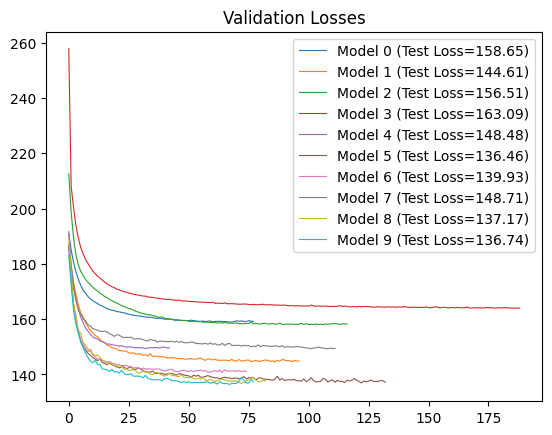

In [10]:
batch_size = 500
backend = keras.backend.backend()

print(f'----------- Test Losses -------------')
_, _, test_batch = get_datasets(batch_size)

for i in range(10):
    root = pathlib.Path(f'./{backend}/VAEDiagonal_v{i}')
    history_path = root.joinpath('history.json')
    weight_path = root.joinpath('model.weights.h5')

    encoder = globals().get(f'get_encoder_v{i}')((28, 28, 1), 2)
    decoder = globals().get(f'get_decoder_v{i}')((28, 28, 1), 2)
    model = VAEDiagonal(encoder=encoder, decoder=decoder, num_mc_samples=1)
    model.build((None, 28, 28, 1))

    model.load_weights(weight_path)
    model.compile()
    res = model.evaluate(test_batch, verbose=False)
    trainable_params = sum(ops.size(w) for w in model.trainable_weights)
    print(f'Model {i}:\tTotal Loss = {res[0]:.2f}\t\tNLL: {res[1]:.2f}\t\tKL: {res[2]:.2f}\t\tParams: {trainable_params:,}')
    with open(history_path, 'r') as f:
        history = json.load(f)
    plt.plot(history['val_loss'], linewidth=0.8, label=f'Model {i} (Test Loss={res[0]:.2f})')
plt.title('Validation Losses')
plt.legend()
plt.show()

The best performance in this run was achieved the version 5 of the encoder-decoder architecture. Depending on the machine we ran this on, it was a toss between versions 5, 8 and 9.

Version 3 is the smallest model, with 20,964 trainable parameters. This model has the smallest KL divergence and the highest total loss. The small KL divergences means that the posterior distribution $q_\phi(z|x)$ does not diverge much from the prior $p_\theta(z)$.
We believe that this, in combination with the fact that the total loss is the highest, is an indication that the model is underfitted, and it is not able to learn the posterior distribution of the latent space.

We observe that, as we increase the model capacity, the KL divergence increases, which means that the posterior distribution $q_\phi(z|x)$ diverges more from the prior $p_\theta(z)$.

For the remaining of the assignment we chose to use model 8 as it offers a good balance between performance and model size.


#### Different Batch Sizes

As part of our earlier experiments, we investigated the effect of different batch sizes on the model performance and determined that a batch size of 500 performed best which is what we used above.
For the sake of completeness, below we trained our final model (version 8) with the following batch sizes: 256, 1024 and 2048 and plot our results.

Batch Size 256 already trained. Skipping...


/Users/thx1138/Documents/MLDS/Term5/DeepLearningAssessment/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Batch Size 512 already trained. Skipping...
Batch Size 1024 already trained. Skipping...
Batch Size 2048 already trained. Skipping...


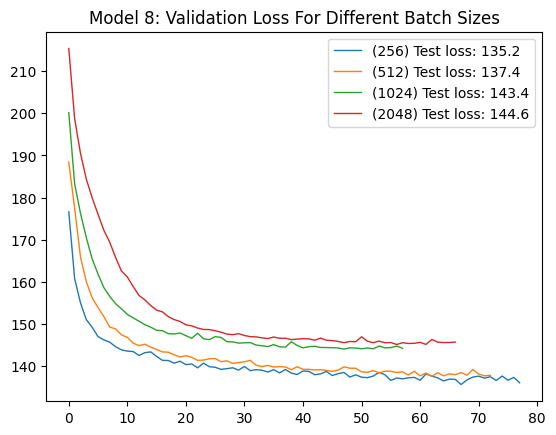

In [11]:
def train_different_batch_sizes():
    # Retrain model 8 with different batch sizes
    backend = keras.backend.backend()
    for batch_size in (256, 512, 1024, 2048):
        train_ds, val_ds, test_ds = get_datasets(batch_size=batch_size)
        data = next(iter(test_ds.take(1)))
        encoder = get_encoder_v8(image_shape=(28, 28, 1), latent_dim=2)
        decoder = get_decoder_v8(image_shape=(28, 28, 1), latent_dim=2)
        root = pathlib.Path(f'./{backend}/VAEDiagonal_v8_{batch_size}')
        root.mkdir(parents=True, exist_ok=True)

        history_path = root.joinpath('history.json')
        weight_path = root.joinpath('model.weights.h5')
        model = VAEDiagonal(encoder=encoder, decoder=decoder, num_mc_samples=1, from_logits=False)
        optimizer = keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        model.compile(optimizer=optimizer)
        early_stopping = EarlyStopping(patience=10)

        if weight_path.exists():
            print(f'Batch Size {batch_size} already trained. Skipping...')
            model(data)
            model.load_weights(weight_path, skip_mismatch=True)
            with open(history_path, 'r') as f:
                history = json.load(f)

            test_loss = model.evaluate(test_ds, verbose=False)[0]
            plt.plot(history['val_loss'], linewidth=1, label=f'({batch_size}) Test loss: {test_loss:.1f}')
            plt.legend()
            continue
        print(f'Training model with batch size {batch_size}...')
        history = model.fit(train_ds, validation_data=val_ds, epochs=1000, callbacks=[early_stopping], verbose=False)

        model.save_weights(weight_path, overwrite=True)
        with open(history_path, 'w') as f:
            json.dump(history.history, f)

        test_loss = model.evaluate(test_ds, verbose=False)[0]
        plt.plot(history.history['val_loss'], linewidth=1, label=f'({batch_size}) Test loss: {test_loss:.1f}')
        plt.legend()
    plt.title(f'Model 8: Validation Loss For Different Batch Sizes')
    plt.show()

train_different_batch_sizes()

Finally, we provide helper function to load the trained `VAEDiagonal` model and the training history for `batch_size=500`.

In [12]:
def get_trained_VAEDiagonal():
    backend = keras.backend.backend()
    weight_path = pathlib.Path(f'./{backend}/VAEDiagonal_v8/model.weights.h5')
    model = VAEDiagonal(encoder=get_encoder_v8((28, 28, 1), 2), decoder=get_decoder_v8((28, 28, 1), 2))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7))
    model(keras.random.normal((1, 28, 28, 1)))
    model.load_weights(weight_path, skip_mismatch=True)
    return model

def get_training_history_VAEDiagonal():
    backend = keras.backend.backend()
    history_path = pathlib.Path(f'./{backend}/VAEDiagonal_v8/history.json')
    with open(history_path, 'r') as f:
        return json.load(f)

c) You should implement a `VAEFullCovariance` class to train a second model using the VAE algorithm, where the encoder network now parameterises a general (full covariance) multivariate Gaussian distribution over the 2-dimensional latent space. You should use the [Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition) to parameterise the covariance matrix. The architectural design of the encoder and decoder network should otherwise be identical to the model you trained in part b).

Your implementation should again follow the specifications:

* The `VAEFullCovariance` class should subclass from the `VAE` class above
* The latent space should have dimension 2
* Your implementation should be entirely using Keras
* The ELBO objective should be approximated using the second form of the SGVB estimator:
$$
\hat{\mathcal{L}}^B(\theta,\phi;x) := \frac{1}{L} \sum_{j=1}^L \log p_\theta(x\mid z^{(j)}) − D_{KL}(q_\phi(z\mid x) || p_\theta(z)),
$$
  * You should set $L=1$ in the model that you train (use a single Monte Carlo sample)
* The likelihood distribution $p_\theta(x\mid z^{(j)})$ should be chosen appropriately for the binary data, as in part b)
* Train your model using the high-level Keras API, and evaluate your trained model on the test set, clearly displaying the loss obtained on the test set.

**(6 marks)**

### Solution

In the previous question we assumed the posterior, $q_\phi(z \mid x)$, was a fully factorised Gaussian. In other words, we assumed no correlation between the latent dimensions which is equivalent to having a diagonal correlation matrix, $\Sigma = \text{diag}(\sigma_i)$, and
$$
q_\phi(z \mid x) = \prod_{i=1}^2 \mathcal{N}(z_i \mid \mu_i, \sigma_i^2).
$$


Now we relax this assumption and allow for correlations between the latent dimensions,
$$
q_\phi(z \mid x) = \mathcal{N}(z \mid \mu, \Sigma)
$$
where $\mu \in \mathbb{R}^l$ and $\Sigma \in \mathbb{R}^{l\times l}$ a symmetric $l\times l$ covariance matrix.
Since $\Sigma$ is symmetric and positive definite, we re-write it in terms of a lower triangular Cholesky factor $L L^\top$, with $l(l+1)/2$ independent components.

The KL-divergence is now given by

\begin{align}
D_{KL}(q_\phi(z\mid x) || p_\theta(z)) = \frac{1}{2}\left[ \mu_q^T\mu_q + \mathrm{Tr} (\Sigma_q) - l - \log \det (\Sigma_q) \right], \tag{1}
\end{align}

and the samples of the posterior distribution describing the latent variable are given by
$$
z = \mu + L \cdot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I). \tag{2}
$$


#### Changes Required

For $l=2$,

$$
L = \begin{bmatrix}L_{00} & 0 \\ L_{10} & L_{11}\end{bmatrix}
$$
where $L_{00}, L_{11} > 0$ since $\Sigma$ is symmetric and positive definite, and,
$$
\log \det \Sigma = 2 \log (L_{00} L_{11}), \qquad \text{Tr}(\Sigma) = L_{00}^2 + L_{10}^2 + L_{11}^2
$$


This means we need to implement the following changes:

1. **Update the Encoder:** The encoder needs to output a mean vector (dim = 2) and the 3 components of $L$. Since we need $L_{00}$ and $L_{11}$ to be positive, we could in theory follow the same approach as above and have the encoder output the log of $L_{00}$ and $L_{11}$. However, this is less numerically stable than having the encoder output the raw $L_{00}$ and $L_{11}$ and using `softplus` to ensure they are positive (and differentiable).
2. **Update the MC Sampling:** The sampling method in the `VAEFullCovariance` class needs to be modified to construct the sample via equation (2) above.
3. **Update the Loss Function:** Update the loss function calculation: KL divergence is now a function of the components of $L$ and the signature of `_sample_z` is different now.
4. **Update the `call` method:** The call method in `VAE` assumes a fully factorised posterior for $z$; we need to update accordingly.


In [13]:
## NOT USED - Switched to v8 due to memory issues later
def get_encoder_full_covariance_old(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Updated version of our final encoder architecture (v9). The head of the
    model has been modified to output the mean vector and the l(l+1)/2 components of the
    lower triangular matrix L

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)  # 28 -> 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(64, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)  # 14 -> 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Flatten()(h)
    h = Dense(512, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)

    # UPDATED CODE:
    # h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    # z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    z_mean = Dense(latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    # lower triangular matrix has l (l+1)/2 components. For l=2 => 3 components
    L = Dense(int(latent_dim * (latent_dim + 1) / 2), kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    L = BatchNormalization()(L)
    return Model(inputs=inputs, outputs=[z_mean, L], name='encoder')


def get_decoder_full_covariance_old(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Define this function for consistency. Simply returns our previous encoder for
    model 9.
    '''
    return get_decoder_v9(image_shape=image_shape, latent_dim=latent_dim)

In [14]:
def get_encoder_full_covariance(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Updated version of our final encoder architecture (v8). The head of the
    model has been modified to output the mean vector and the l(l+1)/2 components of the
    lower triangular matrix L

    Args:
        image_shape: The shape of the images - output tensors
        latent_dim: The latent dimension - dim of the inputs

    Returns: A keras model
    '''
    inputs = Input(shape=image_shape)
    h = Conv2D(32, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(inputs)  # 28 -> 14
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(64, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)  # 14 -> 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Conv2D(128, 3, strides=2, activation=None, use_bias=False, padding='same', kernel_regularizer=REGULARIZER,
               kernel_initializer=INITIALIZER_RELU)(h)  # 14 -> 7
    h = BatchNormalization()(h)
    h = ReLU()(h)
    h = Flatten()(h)
    h = Dense(256, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(128, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    h = Dense(64, activation='relu', kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)

    # UPDATED CODE:
    # h = Dense(2 * latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    # z_mean, z_log_var = ops.split(h, indices_or_sections=2, axis=-1)
    z_mean = Dense(latent_dim, kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    # lower triangular matrix has l (l+1)/2 components. For l=2 => 3 components
    L = Dense(int(latent_dim * (latent_dim + 1) / 2), kernel_regularizer=REGULARIZER, kernel_initializer=INITIALIZER_RELU)(h)
    L = BatchNormalization()(L)
    return Model(inputs=inputs, outputs=[z_mean, L], name='encoder')


def get_decoder_full_covariance(image_shape: Tuple[int, int, int], latent_dim: int):
    '''
    Define this function for consistency. Simply returns our previous encoder for
    model 8.
    '''
    return get_decoder_v8(image_shape=image_shape, latent_dim=latent_dim)


In [15]:
class VAEFullCovariance(VAE):
    def __init__(self, encoder, decoder, num_mc_samples=1, **kwargs):
        """
        You should override this method as necessary in your implementations.
        """
        super().__init__(encoder=encoder, decoder=decoder, num_mc_samples=num_mc_samples, **kwargs)

    def _build_cholesky_2d(self, components):
        '''
        Covert a (batch_size, 3) vector (raw Cholesky components obtained from the encoder) into
        batch_size Cholesky matrices and return a (batch_size, 2, 2) tensor
        Args:
            components: the (batch_size, 3) components [L_00_raw, L_10, L_11_raw]
            where _raw implies that they are not necessary positive.

        Returns: (batch_size, 2, 2) lower-triangular matrices with softplus diagonals.
        '''
        L_00_raw = components[:, 0]
        L_10 = components[:, 1]
        L_11_raw = components[:, 2]

        L_00 = ops.softplus(L_00_raw)
        L_11 = ops.softplus(L_11_raw)

        row1 = ops.stack([L_00, ops.zeros_like(L_00)], axis=-1)
        row2 = ops.stack([L_10, L_11], axis=-1)
        L = ops.stack([row1, row2], axis=1)
        return L

    def _sample_z(self, z_mean, cholesky_raw):
        '''
        Sample z using the mean and standard deviation output from the decoder and Gaussian
        noise epsilon ~ N(0, I) (l dimensional)

            z = mu_q + L_q * epsilon
        Args:
            z_mean: (batch_size, l) The mean of z, obtained using the encoder
            cholesky_raw: (batch_size, 3) The raw components of the Cholesky factor.

        Returns: An (L, 2) tensor, where l=2 is the dimension of the latent space and
        L is the number of Monte Carlo samples required
        '''
        batch_size, latent_dim = ops.shape(z_mean)
        epsilon = keras.random.normal(
            shape=(self.L, batch_size, 2, 1))  # (MC Samples, batch_size, 2, 1), last dim needed for column vectors

        # need MC samples copies of the Cholesky factor
        L_cholesky = self._build_cholesky_2d(cholesky_raw)  # (batch_size, 2, 2)
        L_cholesky = ops.expand_dims(L_cholesky, axis=0)  # (1, batch_size, 2, 2)
        L_cholesky = ops.repeat(L_cholesky, self.L, axis=0)  # (MC Samples, batch_size, 2, 2)

        # need MC samples copies of the mean *column* vector
        z = ops.expand_dims(z_mean, axis=-1)  # (batch_size, 2, 1) Column vectors
        z = ops.expand_dims(z, axis=0)  # (1, batch_size, 2, 1)
        z = ops.repeat(z, self.L, axis=0)  # (MC samples, batch_size, 2, 1)

        z = z + ops.matmul(L_cholesky, epsilon)  # (MC samples, batch_size, 2, 1)
        return ops.squeeze(z, axis=-1)  # (MC samples, batch_size, 2

    def call(self, inputs):
        """
        This method should compute the approximate posterior using the encoder,
        and draw a single sample to pass through the decoder.
        You should override this method as necessary in your implementations.
        """
        z_mean, cholesky_raw = self.encoder(inputs)  # (batch_size, l), (batch_size, l(l+1)/2) where l = 2
        assert ops.shape(z_mean)[-1] == 2

        L_cholesky = self._build_cholesky_2d(cholesky_raw)  # (batch_size, 2, 2)
        epsilon = keras.random.normal(ops.shape(z_mean))  # (batch_size, l)
        epsilon = ops.expand_dims(epsilon, -1)  # convert to a column vector
        z_mean = ops.expand_dims(z_mean, -1)  # convert to a column vector
        z_sample = z_mean + ops.matmul(L_cholesky, epsilon)  # (batch_size, 2, 1)
        z_sample = ops.squeeze(z_sample, axis=-1)
        return self.decoder(z_sample)

    def compute_losses(self, data):
        '''
        Compute the losses. The KL Loss term is the same as the VAE implementation but
        the reconstruction loss will now be the log likelihood of the Bernoulli distribution

        As with the base class, the encoder outputs the mean and log variance of z.
        The decoder outputs the probability $p$ of the Bernoulli distribution
        Args:
            data: a minibatch of the data

        Returns: the total loss, KL loss and negative log-likelihood loss (scalars)
        '''
        eps = 1e-7  # const used for numerical stability (logs)

        z_mean, cholesky_raw = self.encoder(data)  # (batch_size, 2), (batch_size, 3)
        batch_size, latent_dim = ops.shape(z_mean)
        assert latent_dim == 2

        L_cholesky = self._build_cholesky_2d(cholesky_raw)  # (batch_size, 2, 2)
        Sigma = ops.matmul(L_cholesky, ops.transpose(L_cholesky, [0, 2, 1]))  # (batch_size, 2, 2)

        # --------- KL divergence term (analytical) ------------
        # Compute trace of Sigma (sum of diagonal entries)
        trace = Sigma[:, 0, 0] + Sigma[:, 1, 1]  # (batch_size,)

        # Compute log(det(Sigma)) = 2 * (log L_00 + log L_11)
        log_L_00 = ops.log(L_cholesky[:, 0, 0] + eps)
        log_L_11 = ops.log(L_cholesky[:, 1, 1] + eps)
        log_det = 2 * (log_L_00 + log_L_11)

        # Compute squared norm of mean mu^T mu
        z_mean_sq = ops.sum(ops.square(z_mean), axis=-1)  # (batch_size,)

        # KL divergence term (analytical)
        kl_per_sample = 0.5 * (trace + z_mean_sq - log_det - latent_dim)
        kl_loss = ops.mean(kl_per_sample)  # scalar

        # -------- Negative Log Likelihood term (numerically) ----------

        # Sample z \sim q(z|x)
        # z_samples = self._sample_z(z_mean, z_log_var)  # (MC samples, batch, latent_dim) OLD CODE
        z_samples = self._sample_z(z_mean, cholesky_raw)
        z_samples = ops.reshape(z_samples, (self.L * batch_size, latent_dim))  # (MC Samples * batch, latent_dim)

        # Decode the z_samples
        x_pred = self.decoder(z_samples)  # (MC samples * batch, H, W, C)
        _, H, W, C = ops.shape(data)

        # Expand ground truth to match shape
        x_true = ops.expand_dims(data, axis=0)  # (1, batch, H, W, C)
        x_true = ops.repeat(x_true, self.L, axis=0)  # (MC samples, batch, H, W, C)
        x_true = ops.reshape(x_true, ops.shape(x_pred))

        # Clip probs to avoid log(0)
        x_pred = ops.clip(x_pred, eps, 1. - eps)

        # COMPUTE BCE Explicitly (using binary cross entropy loss from keras was leading to instabilities on M1 Max with Tensorflow
        bce_per_pixel = -(
            x_true * ops.log(x_pred) +
            (1. - x_true) * ops.log(1. - x_pred)
        )  # shape: (MC samples * batch, H, W, C)

        # Sum over pixel dimensions (H, W, C) -> total BCE per image
        bce_per_image = ops.sum(bce_per_pixel, axis=[-1, -2, -3])  # shape: (MC samples, batch)

        # Average over MC and batch
        nll_loss = ops.mean(bce_per_image)
        total_loss = kl_loss + nll_loss

        return total_loss, kl_loss, nll_loss

In [16]:
def train_VAEFullCovariance():
    BATCH_SIZE = 500
    backend = keras.backend.backend()

    root = pathlib.Path(f'./{backend}/VAEFullCovariance')
    root.mkdir(parents=True, exist_ok=True)

    history_path = root.joinpath('history.json')
    weight_path = root.joinpath('model.weights.h5')

    train_ds, val_ds, test_ds = get_datasets(batch_size=BATCH_SIZE)
    encoder = get_encoder_full_covariance(image_shape=(28, 28, 1), latent_dim=2)
    decoder = get_decoder_full_covariance(image_shape=(28, 28, 1), latent_dim=2)
    model = VAEFullCovariance(encoder=encoder, decoder=decoder, num_mc_samples=1)
    model(keras.random.normal(shape=(1, 28, 28, 1)))
    optimizer = keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    model.compile(optimizer=optimizer, run_eagerly=keras.backend.backend() == 'tensorflow')
    early_stopping = EarlyStopping(patience=10)

    if weight_path.exists():
        print(f'VAEFullCovariance model already trained. Skipping...')
        model(keras.random.normal((1, 28, 28, 1)))
        model.load_weights(weight_path, skip_mismatch=True)
        with open(history_path, 'r') as f:
            history = json.load(f)
        return model, history
    history = model.fit(train_ds, validation_data=val_ds, epochs=1000, callbacks=[early_stopping], verbose=False)

    model.save_weights(weight_path)
    with open(history_path, 'w') as f:
        json.dump(history.history, f)
    return model, history

model, history = train_VAEFullCovariance()

VAEFullCovariance model already trained. Skipping...


/Users/thx1138/Documents/MLDS/Term5/DeepLearningAssessment/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
def get_trained_VAEFullCovariance():
    backend = keras.backend.backend()
    weight_path = pathlib.Path(f'./{backend}/VAEFullCovariance/model.weights.h5')
    model = VAEFullCovariance(encoder=get_encoder_full_covariance((28, 28, 1), 2), decoder=get_decoder_full_covariance((28, 28, 1), 2))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7))
    model(keras.random.normal((1, 28, 28, 1)))
    model.load_weights(weight_path, skip_mismatch=True)
    return model


def get_training_history_VAEFullCovariance():
    backend = keras.backend.backend()
    history_path = pathlib.Path(f'./{backend}/VAEFullCovariance/history.json')
    with open(history_path, 'r') as f:
        return json.load(f)

### Compare the performance of the `VAEDiagonal` Vs `VAEFullCovariance`

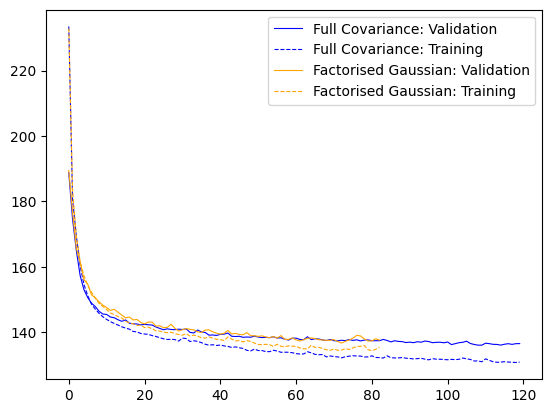

In [18]:
full_cov_history = get_training_history_VAEFullCovariance()
diag_history = get_training_history_VAEDiagonal()
plt.plot(full_cov_history['val_loss'], linewidth=0.8, color='b', label='Full Covariance: Validation')
plt.plot(full_cov_history['loss'], linewidth=0.8, color='b', linestyle='--', label='Full Covariance: Training')
plt.plot(diag_history['val_loss'], linewidth=0.8, color='orange', label='Factorised Gaussian: Validation')
plt.plot(diag_history['loss'], linewidth=0.8, color='orange', linestyle='--', label='Factorised Gaussian: Training')
plt.legend()
plt.show()


In [19]:
full_model = get_trained_VAEFullCovariance()
diag_model = get_trained_VAEDiagonal()

_, _, test_ds = get_datasets(batch_size=500)
full_model_res = full_model.evaluate(test_ds, verbose=False)
diag_model_res = diag_model.evaluate(test_ds, verbose=False)

print(f'----------------Test Losses----------------')
print(f'VAEFullCovariance: Total Loss: {full_model_res[0]:.2f}\t\tNLL: {full_model_res[1]:.2f}\t\tKL: {full_model_res[2]:.2f}')
print(f'VAEDiagonal:       Total Loss: {diag_model_res[0]:.2f}\t\tNLL: {diag_model_res[1]:.2f}\t\tKL: {diag_model_res[2]:.2f}')

----------------Test Losses----------------
VAEFullCovariance: Total Loss: 135.81		NLL: 128.45		KL: 7.36
VAEDiagonal:       Total Loss: 137.14		NLL: 129.98		KL: 7.16


#### Model Comparison: `VAEDiagonal` Vs `VAEFullCovariance`

From the test losses we observe that, for our architecture, the full covariance model performs better. However, during our experiments, we also tried an implementation of both models based on the encoder-decoder architectures of version 9 and found that, in that case, `VAEFullCovariance` did not improve the performance.

Next we look visualise the effect of each model on a sample image.

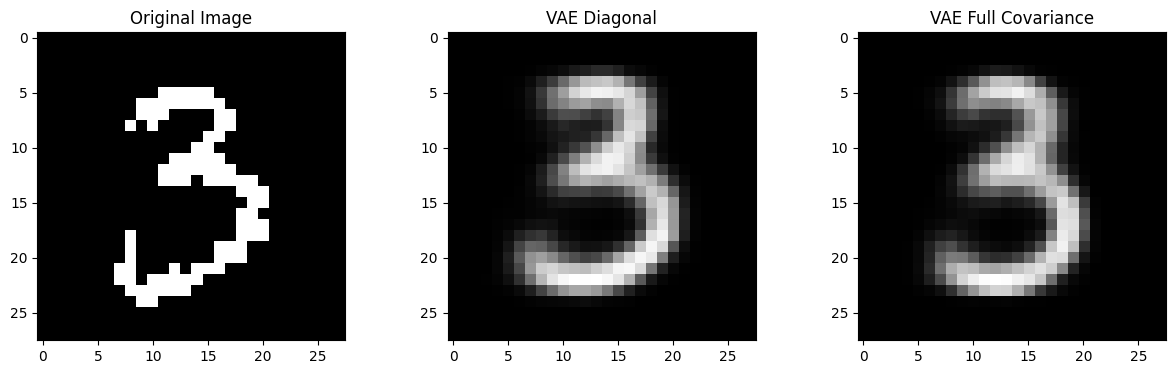

In [37]:
train_ds, val_ds, test_ds = get_datasets(batch_size=500)
org_image = next(iter(test_ds.shuffle(500).take(1)))

vaediag = get_trained_VAEDiagonal()
vaefull = get_trained_VAEFullCovariance()

vaediag_img = vaediag(org_image, training=False)
vaefull_img = vaefull(org_image, training=False)

# plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(org_image[0, :, :, 0], cmap='gray')
plt.title('Original Image')
plt.subplot(1, 3, 2)
plt.imshow(vaediag_img[0, :, :, 0].detach().cpu(), cmap='gray')
plt.title('VAE Diagonal')
plt.subplot(1, 3, 3)
plt.imshow(vaefull_img[0, :, :, 0].detach().cpu(), cmap='gray')
plt.title('VAE Full Covariance')
plt.show()

### Question 2 (Total 14 marks)

The importance weighted autoencoder (IWAE) objective is defined as

$$
\mathcal{L}_{IWAE}^k(\theta, \phi; x) := \mathbb{E}_{z_1,\ldots,z_k\sim q_\phi({z}\mid {x})} \left[ \log \frac{1}{k} \sum_{i=1}^k \frac{p_\theta({x}, {z_i})}{q_\phi({z_i}\mid {x})} \right],
$$

where $k\ge 1$ is a positive integer. The IWAE objective can be used as an optimisation objective instead of the VAE ELBO $\mathcal{L}_{VAE}$. The IWAE objective was introduced in the following paper, where it is shown that, similar to the VAE ELBO, $\mathcal{L}_{IWAE}^k$ is a lower bound on the marginal likelihood, and that $\log p_\theta(x) \ge \mathcal{L}_{IWAE}^{k+1} \ge \mathcal{L}_{IWAE}^k$. It is also shown (under certain conditions on $q_\phi(z\mid x)$) that $\mathcal{L}_{IWAE}^k \to \log p_\theta(x)$ as $k\to\infty$.

* Burda, Y., Grosse, R. and Salakhutdinov, R. (2015), "Importance Weighted Autoencoders", arXiv preprint, abs/1509.00519.

a) In Burda et al, it is proposed to use $\mathcal{L}_{IWAE}^k$ with $k=5000$ as a approximation of the true log-likelihood $\log p_\theta(x)$.

Use this approximation of the log-likelihood to compute and display the negative log-likelihood (NLL) for the models trained in parts 1b) and 1c). Use a single Monte Carlo sample for each $z_1,\ldots,z_k$ (in other words, take a single sample of the vector $(z_1,\ldots,z_k)$) in the approximation of the expectation above.

_If you could not successfully implement the `VAEDiagonal` or `VAEFullCovariance` classes in questions 1b) and 1c), you can complete this question using the base `VAE` class provided for you, and a trained encoder/decoder as in the week 9 lecture notes._

**(4 marks)**

### Solution

The importance weighted objective can be computed using MC sampling for the expectation over $z_1, \ldots, z_k$,

$$
\mathcal{L}_{IWAE}^k(\theta, \phi; x) \approx \frac{1}{L}\sum_{j=1}^L \left[ \log \frac{1}{k} \sum_{i=1}^k \frac{p_\theta({x}, {z^{(j)}_i})}{q_\phi({z^{(j)}_i}\mid {x})} \right],
$$

where we draw $L$ $(z_1, z_2, \ldots, z_k)$ samples and, for each sample of size $k$, we compute
$$
\log \frac{1}{k} \sum_{i=1}^k \frac{p_\theta({x}, {z^{(j)}_i})}{q_\phi({z^{(j)}_i}\mid {x})},
$$
where $p_\theta\left(x, z_i\right) = p_\theta(x | z_i) p_\theta(z_i)$.
We are interested in $L=1$, in which case,
$$
\mathcal{L}_{IWAE}^k(\theta, \phi; x) \approx  \log \frac{1}{k} \sum_{i=1}^k \frac{p_\theta({x}, {z_i})}{q_\phi({z_i}\mid {x})} \equiv \log \frac{1}{k}\sum_{i=1}^k w_i,
$$
where
$$
w_i = \frac{p_\theta({x}| {z_i}) p_\theta(z_i)}{q_\phi({z_i}\mid {x})} = \exp \Big(\log(p_\theta(x| z_i)) + \log (p_\theta(z_i)) - \log (q_\phi(z_i|x)) \Big)
$$
and $\mathcal{L}_{IWAE} = \text{logsumexp}\left( \log w_1 + \ldots + \log w_k\right) - \log k$.

In order to compute these weights we need the log likelihood of $p_\theta(x|z_i)$, $p_\theta(z_i)$ and $q_\phi(z_i|x)$.

* $x|z_i \sim \text{Bernoulli}(\hat{x}_i)$ where $\hat{x}_i$ is the output of the decoder. Hence,
$$
\log p_\theta(x |z_i) = x \cdot \log(\hat{x}_i) - (1-x) \cdot \log(1-\hat{x}_i) \qquad \text{\small(sum over pixels and samples implied)}
$$
* $z_i \sim \mathcal{N}(0, I)$ is the latent space prior which we have taken to be a standard Gaussian. Hence
$$
\log p_\theta(z_i) = -\frac{1}{2}\left(\|z_i\|^2 + 2 l \log (2\pi) \right)
$$
* $z_i|x \sim \mathcal{N}\left(\mu, \text{diag}(\sigma)\right)$ for the fully factorised Gaussian (`VAEDiagonal`) and $z_i|x \sim \mathcal{N}\left( \mu, \Sigma\right)$ for a multivariate Gaussian with full covariance (`VAEFullCovariance`). Hence,
$$
\log q_\phi(z_i|x) = -\frac{1}{2}\left[\sum_{j=1}^l \frac{(z_{ij} - \mu_j)^2}{\sigma_j^2} + \sum_{j=1}^l \log(\sigma_j^2) + l \log(2\pi) \right]
\qquad \text{\small(fully factorised)}
$$
$$
\log q_\phi(z_i|x) = -\frac{1}{2}\left[\|L^{-1} (z_i - \mu)\|^2 + \log \det \Sigma + l \log(2\pi) \right]
\qquad \text{\small(full covariance)}
$$

Note that, to avoid matrix inversion which may cause instabilities, we need to solve
$$
L x=z_i - \mu
$$
for $x$ (we can do this by hand in 2 dimensions but here we use the `solve_triangular` method from `keras.ops.linalg`).


**Implementation**:

1. Define functions that compute all the log likelihoods. $p_\theta(x|z)$ and $p_\theta(z)$ are the same for both models, but we need to implement $q_\phi(z|x)$ for each model, as explained above. This allows us to test each one independently and verify the tensor dimensions and outputs. (_Code design choice: Attach the appropriate log likelihood function for $q_\phi(z|x)$ to each model class_)
2. Define a function that computes the negative log likelihood using the functions defined in 1.

Step 2 led to massive memory issues, even with small batch sizes, unless we restricted to a very small number of samples. Eventually we managed to resolve the issue by batching the images and partitioning the sampling too. Since the assignment did not specify the dataset to use, we used the test data (using the training data was impossible due to memory issues).


In [21]:
def log_q_z_given_x_diag_covariance(self, z, z_mean, z_log_var):
    '''
    Compute the log likelihood for the posterior distribution of the latent
    space for fully factorised gaussian case - to be attached to the VAEDiagonal
    class

    Args:
        z: (MC samples, batch_size, 2)
        z_mean: (batch_size, 2)
        z_log_var: (batch_size, 2), log_var of the posterior distribution

    Returns: (MC samples * batch_size, ), the log likelihood of z given x
    '''
    mc_samples, batch_size, latent_dim = keras.ops.shape(z)  # mc_samples = self.L

    # mahalanobis distance
    z_centered = z - keras.ops.expand_dims(z_mean, 0)
    z_log_var = keras.ops.expand_dims(z_log_var, 0)
    inv_var = keras.ops.exp(-z_log_var)
    maha = keras.ops.sum(z_centered ** 2 * inv_var, axis=-1)

    # log determinant
    log_det = keras.ops.sum(z_log_var, axis=-1)

    # log likelihood
    return -0.5 * (maha + log_det + latent_dim * keras.ops.log(2 * np.pi))


def log_q_z_given_x_full_covariance(self, z, z_mean, cholesky_params):
    '''
    Compute the log likelihood for the posterior distribution of the latent
    space for full covariance model - to be attached to the VAEFullCovariance
    class

    Args:
        z: (MC samples, batch_size, 2)
        z_mean: (batch_size, 2)
        cholesky_params: (batch_size, 3), raw components of the Cholesky factor

    Returns: (MC samples * batch_size, ), the log likelihood of z given x
    '''
    eps = 1e-7  # numerical stability
    mc_samples, batch_size, latent_dim = keras.ops.shape(z)  # mc_samples = self.L

    L = self._build_cholesky_2d(cholesky_params)  # (batch_size, 2, 2)

    # mahalanobis distance
    z_centered = z - keras.ops.expand_dims(z_mean, 0)
    z_centered = keras.ops.expand_dims(z_centered, -1)  # (MC samples, batch_size, 2, 1)
    L_exp = keras.ops.expand_dims(L, 0)  # (1, batch_size, 2, 2)
    x = keras.ops.linalg.solve_triangular(L_exp, z_centered, lower=True)
    x = keras.ops.squeeze(x, axis=-1)  # (MC samples, batch_size, 2)
    maha = keras.ops.sum(x ** 2, axis=-1)  # (MC samples, batch_size)

    # log determinant
    log_L_00 = ops.log(L[:, 0, 0] + eps)
    log_L_11 = ops.log(L[:, 1, 1] + eps)
    log_det = 2 * (log_L_00 + log_L_11)  # (batch_size,)
    log_det = ops.expand_dims(log_det, axis=0)  # (batch_size, 1)

    # log likelihood
    return -0.5 * (maha + log_det + latent_dim * keras.ops.log(2 * np.pi))


def log_p_x_given_z(x_pred, x_true):
    '''
    Compute the log likelihood for the posterior distribution of
    the reconstructed images (Bernoulli)
    Args:
        x_pred: reconstructed images (MC samples, batch_size, 28, 28, 1
        x_true: input images (batch_size, 28, 28, 1)

    Returns: (batch_size,) Binary cross entropy loss per prediction
    '''
    eps = 1e-7
    x_pred = ops.clip(x_pred, eps, 1 - eps) # for numerical stability
    x_true = ops.expand_dims(x_true, axis=0) # (1, batch_size, 28, 28, 1)

    # Log p(x|z_k) under Bernoulli decoder
    ll_per_image = -ops.sum(x_true * ops.log(x_pred) + (1. - x_true) *
                            ops.log(1. - x_pred), axis=[-1, -2, -3])  # (MC samples, batch_size)
    return ll_per_image


def log_p_z_prior(z_samples):
    '''
    Compute the log likelihood of the prior for the latent space (normal
    distribution)

    Args:
        z_samples: (MC samples, batch_size, 2)

    Returns:

    '''
    return -0.5 * ops.sum(z_samples ** 2 + ops.log(2 * np.pi), axis=-1)

In [23]:
def compute_IWAE_nll(model, dataset, k=5000, k_chunk_size=25):
    '''
    Implementation of the IWAE negative log likelihood calculation

    Args:
        model: keras model that has an encoder, a decoder objects, and _sample_z and
        log_q_z_given_x functions
        dataset: MNIST binarized dataset split
        k: Number of samples
        k_chunk_size: Chunk size of samples  (introduced for memory management and to speed the process)

    Returns: float - the negative log likelihood computed using the IWAE approach

    '''
    running_total = 0
    sample_count = 0

    model.L = k_chunk_size
    for i, x in enumerate(dataset):
        log_ws = []
        batch_size = ops.shape(x)[0]
        # print(f'[{i+1}/{batches}]')
        # Step 1: encode the images
        encoder_output = model.encoder(x, training=False)
        for j in range(k//k_chunk_size):
            # print(f'[{i + 1}/{batches}] [{j+1}/{k// k_chunk_size}]')
            # Step 2: sample model.L MC samples
            z_samples = model._sample_z(encoder_output[0], encoder_output[1])

            # Step 3: compute (MC samples, batch_size) image predictions using the decoder
            x_pred = model.decoder(ops.reshape(z_samples, (k_chunk_size * batch_size, 2)), training=False)
            x_pred = ops.reshape(x_pred, (k_chunk_size, batch_size, 28, 28, 1))

            # compute w_i
            x_given_z = log_p_x_given_z(x_pred=x_pred, x_true=x)
            z_prior = log_p_z_prior(z_samples=z_samples)
            z_given_x = model.log_q_z_given_x(z_samples, encoder_output[0], encoder_output[1])
            log_ws.append(x_given_z + z_prior - z_given_x)  # List of l_ws of shape (k, batch_size)
        log_ws = ops.concatenate(log_ws) # tensor with the k samples per image in the batch, images in the batch
        log_wi = ops.logsumexp(log_ws, axis=0) - ops.log(float(k))  # shape (batch_size,)
        running_total += ops.sum(log_wi)
        sample_count += x.shape[0]
    return -float(running_total / sample_count)

In [ ]:
import types
def clear_cache():
  keras.backend.clear_session()
  if keras.backend.backend() == 'torch':
    if torch.cuda.is_available():
      torch.cuda.empty_cache()
    else:
      torch.mps.empty_cache()


def do_IWAE_compute():
  k = 5000
  k_chunk_size = 25 # needs to be a divisor of k
  ds = tfds.load('binarized_mnist', data_dir='data', split='test')
  dl = prepare_dataset(train_ds, batch_size=2000, shuffle=False)

  vae_diag = get_trained_VAEDiagonal()
  vae_full = get_trained_VAEFullCovariance()

  vae_diag.log_q_z_given_x = types.MethodType(log_q_z_given_x_diag_covariance, vae_diag)
  vae_full.log_q_z_given_x = types.MethodType(log_q_z_given_x_full_covariance, vae_full)
  clear_cache()
  if keras.backend.backend() == 'torch':
      with torch.inference_mode():
          vae_diag_iwae_nll = compute_IWAE_nll(model=vae_diag, dataset=dl, k=k, k_chunk_size=k_chunk_size)
          clear_cache()
          vae_full_iwae_nll = compute_IWAE_nll(model=vae_full, dataset=dl, k=k, k_chunk_size=k_chunk_size)
  else:
      vae_diag_iwae_nll = compute_IWAE_nll(model=vae_diag, dataset=dl, k=k, k_chunk_size=k_chunk_size)
      vae_full_iwae_nll = compute_IWAE_nll(model=vae_full, dataset=dl, k=k, k_chunk_size=k_chunk_size)
  return vae_diag_iwae_nll, vae_full_iwae_nll

iwae_diag_nll, iwae_full_nll = do_IWAE_compute()
print(f'VAE Diagonal IWAE NLL:          {iwae_diag_nll:.2f}')
print(f'VAE Full Covariance IWAE NLL:   {iwae_full_nll:.2f}')

/usr/local/lib/python3.11/dist-packages/keras/src/backend/common/backend_utils.py:91: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=2, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/backend/common/backend_utils.py:91: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas t

VAE Diagonal IWAE NLL:          -135.75
VAE Full Covariance IWAE NLL:   -129.36


b) You should now train new encoder and decoder networks using the IWAE objective. The architectural design of the encoder and decoder networks should be identical to any previously trained models, with the encoder parameterising a fully factorised (diagonal) Gaussian for the approximate posterior $q_\phi(z \mid x)$ (as in the `VAE` and `VAEDiagonal` classes). You should use a `IWAEDiagonal` class to implement this (NB you may possibly have implemented this class in part a)).

Your implementation should follow the specifications:

* The `IWAEDiagonal` class should subclass from the `VAE` class or the `VAEDiagonal` class
* The latent space should have dimension 2
* Your implementation should be entirely using Keras
* The maximisation objective should be the IWAE objective $\mathcal{L}_{IWAE}^k$ with $k=50$. The expectation in the IWAE objective should be approximated using a single Monte Carlo sample for each $z_1,\ldots,z_k$
  * You should set $k=50$ in the model that you train, but your model class implementation should work for general $k$
* The likelihood distribution $p_\theta(x\mid z^{(j)})$ should be chosen appropriately for the binary data, as in question 1
* Train your model using the high-level Keras API, and evaluate your trained model on the test set, clearly displaying the loss obtained on the test set.

_Make sure to save your model as it will be used again in later questions._

**(3 marks)**

### Solution

**Comment on `k` and `k_chunk_size`**

In the previous question we had memory issues so we have implemented our class such that it computes the `k` importance sampling weights, $w_i$, in batches of size `k_chunk_size` at a time, storing them in an array, and averaging at the end. This way we do not need to hold all `k` decoded images in memory.

In [24]:
class IWAEDiagonal(VAEDiagonal):

    def __init__(self, encoder, decoder, k=50, k_chunk_size=25, num_mc_samples=1, **kwargs):
        """
        You should override this method as necessary in your implementations.
        """
        super().__init__(encoder=encoder, decoder=decoder, num_mc_samples=num_mc_samples, **kwargs)
        self.k = k
        if k % k_chunk_size == 0:
            self.n = k // k_chunk_size
            self.k_chunk_size = k_chunk_size
        else:
            self.n = k
            self.k_chunk_size = 1

    def _sample_z(self, z_mean, z_log_var, samples):
        '''
        Sample z using the mean and standard deviation output from the decoder and Gaussian
        noise epsilon ~ N(0, 1) (l dimensional)

            z = mu_q + std_q * epsilon
        Args:
            z_mean: The mean of z, obtained using the encoder
            z_log_var: The log variance of z, obtained using the decoder
            samples: number of samples to return

        Returns: An (samples, l) tensor, where l is the dimension of the latent space and
        samples is the number of samples required
        '''
        batch_size, latent_dim = ops.shape(z_mean)

        # Sample epsilon ~ N(0, 1)
        epsilon = keras.random.normal(shape=(samples, batch_size, latent_dim))

        # Reparameterisation trick
        z_std = ops.exp(0.5 * z_log_var)
        z_samples = z_mean + z_std * epsilon  # shape: (L, B, l)

        return z_samples

    def log_q_z_given_x(self, z_samples, z_mean, z_log_var):
        '''
        Compute the log likelihood for the posterior distribution of the latent
        space for fully factorised gaussian case - to be attached to the VAEDiagonal
        class

        Args:
            z_samples: (MC samples, batch_size, 2)
            z_mean: (batch_size, 2)
            z_log_var: (batch_size, 2), log_var of the posterior distribution

        Returns: (MC samples * batch_size, ), the log likelihood of z given x
        '''
        mc_samples, batch_size, latent_dim = keras.ops.shape(z_samples)  # mc_samples = self.L

        # mahalanobis distance
        z_centered = z_samples - keras.ops.expand_dims(z_mean, 0)
        z_log_var = keras.ops.expand_dims(z_log_var, 0)
        inv_var = keras.ops.exp(-z_log_var)
        maha = keras.ops.sum(z_centered ** 2 * inv_var, axis=-1)

        # log determinant
        log_det = keras.ops.sum(z_log_var, axis=-1)

        # log likelihood
        return -0.5 * (maha + log_det + latent_dim * keras.ops.log(2 * np.pi))


    def bce_loss(self, x_true, z_mean, z_log_var):
        '''
        Compute NLL loss for VAE

        Args:
            x_true: batch of input images
            z_mean: latent space mean - encoder output
            z_log_var: latent space log variance - encoder output

        Returns: scalar (float)
        '''
        # NLL/BCE Loss
        # Sample z ~ q(z|x)
        eps = 1e-7
        batch_size, latent_dim = ops.shape(z_mean)
        z_samples = self._sample_z(z_mean, z_log_var, self.L)  # (MC samples, batch, latent_dim)
        z_samples = ops.reshape(z_samples, (self.L * batch_size, latent_dim))  # (MC Samples * batch, latent_dim)

        # Decode: returns logits or probabilities
        x_pred = self.decoder(z_samples)  # (MC samples * batch, H, W, C)
        _, H, W, C = ops.shape(x_true)

        # Expand ground truth to match shape
        x_true = ops.expand_dims(x_true, axis=0)  # (1, batch, H, W, C)
        x_true = ops.repeat(x_true, self.L, axis=0)  # (MC samples, batch, H, W, C)
        x_true = ops.reshape(x_true, ops.shape(x_pred))

        # Clip probs to avoid log(0)
        x_pred = ops.clip(x_pred, eps, 1. - eps)

        bce_per_pixel = -(
            x_true * ops.log(x_pred) +
            (1. - x_true) * ops.log(1. - x_pred)
        )  # shape: (MC samples * batch, H, W, C)

        # Sum over pixel dimensions (H, W, C) -> total BCE per image
        bce_per_image = ops.sum(bce_per_pixel, axis=[-1, -2, -3])  # shape: (MC samples, batch)

        # Average over MC and batch
        nll_loss = ops.mean(bce_per_image)
        return nll_loss

    def kl_divergence(self, z_mean, z_log_var):
        '''
        Compute KL divergence analytically for VAE

        Args:
            z_mean: latent space mean - encoder output
            z_log_var: latent space log variance - encoder output

        Returns: scalar (float)
        '''
        # KL divergence term (analytical)
        kl_per_sample = 0.5 * ops.sum(
            ops.square(z_mean) + ops.exp(z_log_var) - 1 - z_log_var,
            axis=-1  # sum over latent dim
        )
        kl = ops.mean(kl_per_sample)  # scalar
        return kl

    def iwae_loss(self, x_true, z_mean, z_log_var):
        eps = 1e-7
        _, H, W, C = ops.shape(x_true)
        batch_size = ops.shape(x_true)[0]
        z_mean = ops.squeeze(z_mean, axis=0)
        z_log_var = ops.squeeze(z_log_var, axis=0)
        log_w = []
        for i in range(self.n):
            # Sample z: shape (k_chunk_size, batch_size, l)
            z_samples = self._sample_z(z_mean, z_log_var, samples=self.k_chunk_size)

            # Compute (MC samples, batch_size) image predictions using the decoder
            x_pred = self.decoder(ops.reshape(z_samples, (self.k_chunk_size * batch_size, 2)), training=True)
            x_pred = ops.reshape(x_pred, (self.k_chunk_size, batch_size, H, W, C))
            x_pred = ops.clip(x_pred, eps, 1 - eps)

            # log p(x|z)
            x_true_expanded = ops.expand_dims(x_true, axis=0)  # (1, batch_size, 28, 28, 1)
            log_p_x_given_z = ops.sum(x_true_expanded * ops.log(x_pred) + (1. - x_true_expanded) * ops.log(1. - x_pred),
                                      axis=[-1, -2, -3])

            # log p(z)
            log_p_z = -0.5 * ops.sum(z_samples ** 2 + ops.log(2 * np.pi), axis=-1)  # (k, B)

            # log q(z|x)
            log_q_z_given_x = self.log_q_z_given_x(z_samples, z_mean, z_log_var)
            log_w_chunk = log_p_x_given_z + log_p_z - log_q_z_given_x  # (k_chunk_size, batch_size)

            # Ensure log_w_chunk has 3 dimensions for concatenation
            if len(log_w_chunk.shape) == 2:
              log_w_chunk = ops.expand_dims(log_w_chunk, axis=0)  # Add a dimension if necessary

            log_w.append(log_w_chunk)
        log_w = ops.concatenate(log_w, axis=0)  # tensor with the (k samples per image in the batch, images in the batch)

        # Reshape log_w if necessary to match the expected shape
        log_w = ops.reshape(log_w, (self.k, batch_size))

        log_w = ops.logsumexp(log_w, axis=0) - ops.log(float(self.k))  # shape (batch_size,)
        return -ops.mean(log_w)

    def compute_losses(self, data):
        '''
        Compute the losses. Now needs to be IWAE NLL
        Args:
            data: a minibatch of the data

        Returns: the IWAE NLL
        '''
        # Encode the data -> image shape to latent dim
        z_mean, z_log_var = self.encoder(data)  # (batch, latent_dim)
        kl = self.kl_divergence(z_mean=z_mean, z_log_var=z_log_var)
        nll_loss = self.bce_loss(x_true=data, z_mean=z_mean, z_log_var=z_log_var)
        iwae_loss = self.iwae_loss(x_true=data, z_mean=z_mean, z_log_var=z_log_var)

        return iwae_loss, kl, nll_loss

In [25]:
def train_IWAEDiagonal():
    batch_size = 500
    backend = keras.backend.backend()

    root = pathlib.Path(f'./{backend}/IWAEDiagonal')
    root.mkdir(parents=True, exist_ok=True)

    history_path = root.joinpath('history.json')
    model_weights_path = root.joinpath('model.weights.h5')
    train_ds, val_ds, test_ds = get_datasets(batch_size=batch_size)
    encoder = get_encoder_v8(image_shape=(28, 28, 1), latent_dim=2)
    decoder = get_decoder_v8(image_shape=(28, 28, 1), latent_dim=2)
    model = IWAEDiagonal(encoder=encoder, decoder=decoder, k=50, k_chunk_size=25, num_mc_samples=1)
    model(keras.random.normal(shape=(1, 28, 28, 1)))
    optimizer = keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    model.compile(optimizer=optimizer, run_eagerly=keras.backend.backend() == 'tensorflow')
    early_stopping = EarlyStopping(patience=10)
    if model_weights_path.exists():
        print('Model already trained. Skipping...')
        return
    history = model.fit(train_ds, validation_data=val_ds, epochs=1000, callbacks=[early_stopping], verbose=True)

    model.save_weights(model_weights_path)
    with open(history_path, 'w') as f:
        json.dump(history.history, f)

In [26]:
def get_trained_IWAEDiagonal():
    backend = keras.backend.backend()
    root = pathlib.Path(f'./{backend}/IWAEDiagonal')
    model_weights_path = root.joinpath('model.weights.h5')
    encoder = get_encoder_v8(image_shape=(28, 28, 1), latent_dim=2)
    decoder = get_decoder_v8(image_shape=(28, 28, 1), latent_dim=2)
    model = IWAEDiagonal(encoder=encoder, decoder=decoder, num_mc_samples=1)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7))
    model(keras.random.normal(shape=(1, 28, 28, 1)))
    model.load_weights(model_weights_path, skip_mismatch=True)
    return model

def get_training_history_IWAEDiagonal():
    backend = keras.backend.backend()
    root = pathlib.Path(f'./{backend}/IWAEDiagonal')
    history_path = root.joinpath('history.json')
    with open(history_path, 'r') as f:
        return json.load(f)


In [27]:
train_IWAEDiagonal()

Model already trained. Skipping...


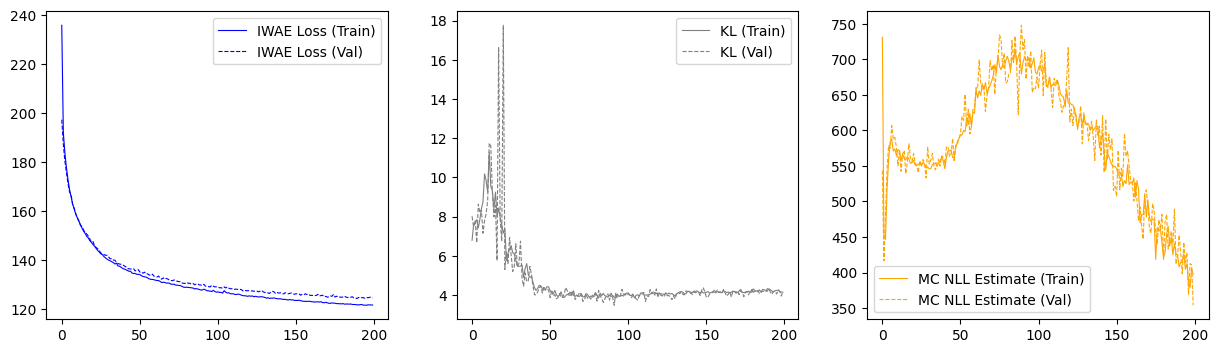

In [29]:
history = get_training_history_IWAEDiagonal()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history['loss'], linewidth=0.8, color='b', label='IWAE Loss (Train)')
plt.plot(history['val_loss'], linewidth=0.8, color='b', linestyle='--', label='IWAE Loss (Val)')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['kl'], linewidth=0.8, color='grey', label='KL (Train)')
plt.plot(history['val_kl'], linewidth=0.8, color='grey', linestyle='--', label='KL (Val)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['nll'], linewidth=0.8, color='orange', label='MC NLL Estimate (Train)')
plt.plot(history['val_nll'], linewidth=0.8, color='orange', linestyle='--', label='MC NLL Estimate (Val)')
plt.legend()
plt.show()

In [30]:
model = get_trained_IWAEDiagonal()
train_ds, val_ds, test_ds = get_datasets()
model.evaluate(test_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - kl: 4.1889 - loss: 124.7545 - nll: 353.1237


[124.95549774169922, 357.00640869140625, 4.190710544586182]

### Comparison with IWAE NLL for `VAEDiagonal` and `VAEFullCovariance`

In the previous exercise we computed the negative IWAE likelihood estimate for the test data. We found that for `VAEDiagonal` it was -135.75 and for `VAEFullCovariance` it was -129.36. Here our training achieved -124.75 (but of course it was trained to optimise for this loss function).

Below we compare the images generated.

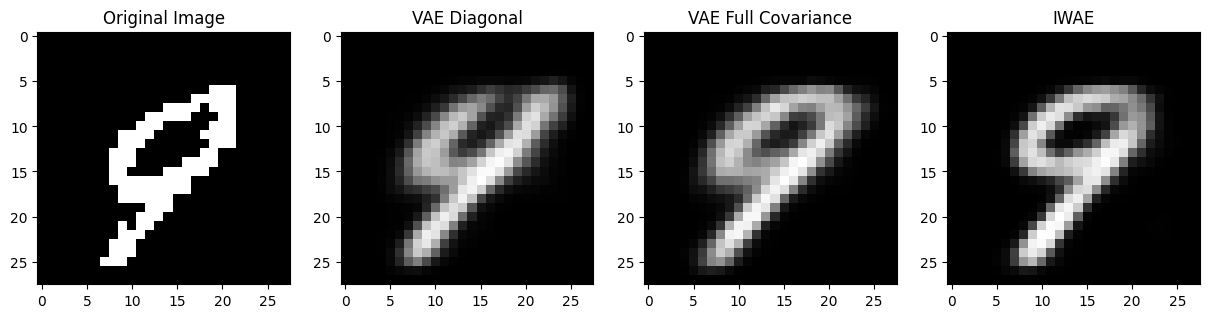

In [31]:
org_image = next(iter(test_ds.take(1)))

vaediag = get_trained_VAEDiagonal()
vaefull = get_trained_VAEFullCovariance()
iwaediag = model

vaediag_img = vaediag(org_image, training=False)
vaefull_img = vaefull(org_image, training=False)
iwaediag_img = iwaediag(org_image, training=False)

# plot side by side
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(org_image[0, :, :, 0], cmap='gray')
plt.title('Original Image')
plt.subplot(1, 4, 2)
plt.imshow(vaediag_img[0, :, :, 0].detach().cpu(), cmap='gray')
plt.title('VAE Diagonal')
plt.subplot(1, 4, 3)
plt.imshow(vaefull_img[0, :, :, 0].detach().cpu(), cmap='gray')
plt.title('VAE Full Covariance')
plt.subplot(1, 4, 4)
plt.imshow(iwaediag_img[0, :, :, 0].detach().cpu(), cmap='gray')
plt.title('IWAE')
plt.show()


c) We define the distribution $q^k_{IWAE}(z\mid x)$ by

$$
q^k_{IWAE}(z\mid x) = \mathbb{E}_{z_2,\ldots,z_k\sim q_\phi(z\mid x)}\left[ \frac{p_\theta(x, z)}{\frac{1}{k} \left( \frac{p_\theta(x, z)}{q_\phi(z \mid x)} + \sum_{j=2}^k \frac{p_\theta(x, z_j)}{q_\phi(z_j \mid x)} \right)} \right].
$$

Prove that $q^k_{IWAE}(z\mid x)$ is a valid normalised distribution; that is, $\int_z q^k_{IWAE}(z\mid x) dz = 1$.

**(3 marks)**

We need to show that $\int_z q^k_{IWAE}(z\mid x) dz = 1$.
Let
$$
w(z_i) = \frac{p_\theta(x, z_i)}{q_\phi(z_i \mid x)}
$$.

where $z_i \sim q_\phi(z|x)$.
Substituting this into the definition of $q^k_{IWAE}(z\mid x)$ gives:
$$
q^k_{IWAE}(z\mid x) = \mathbb{E}_{z_2,\ldots,z_k\sim q_\phi(z\mid x)}\left[ \frac{w(z) q_\phi(z \mid x)}{\frac{1}{k} \left( w(z) + \sum_{j=2}^k w(z_j) \right)} \right]
$$

\begin{align}
\Rightarrow \int_z q^k_{IWAE}(z\mid x) dz &= \int_z \left( \int_{z_2} \ldots \int_{z_k} \prod_{j=2}^k q_\phi(z_j \mid x) \left[ \frac{k \cdot w(z) q_\phi(z \mid x)}{w(z) + \sum_{l=2}^k w(z_l)} \right] dz_k \ldots dz_2 \right) dz\\
&= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_1)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
\end{align}

Let $I_m$ be the integral where the numerator contains $w(z_m)$ instead of $w(z_1)$:
$$
I_m = \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
The integral we want to compute is $I_1$.

Due to the symmetry of the integration measure $\prod_{j=1}^k q_\phi(z_j \mid x) dz_j$ and the sum $\sum_{i=1}^k w(z_i)$ with respect to permutation of the variables $z_1, \ldots, z_k$, the value of the integral $I_m$ must be the same for all $m \in \{1, \ldots, k\}$. That is, $I_1 = I_2 = \ldots = I_k$.

We consider the sum of these integrals:
$$
\sum_{m=1}^k I_m = \sum_{m=1}^k \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
Assuming convergence, we can exchange the order of summation and integration,
\begin{align}
\sum_{m=1}^k I_m &= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \sum_{m=1}^k \left[ \frac{k \cdot w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1\\
&= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \sum_{m=1}^k w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
\end{align}
The term in the square brackets simplifies: $\frac{k \sum_{m=1}^k w(z_m)}{\sum_{i=1}^k w(z_i)} = k$.
\begin{align}
&= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) k \ dz_k \ldots dz_1\\
= k \int_{z_1} q_\phi(z_1 \mid x) dz_1 \int_{z_2} q_\phi(z_2 \mid x) dz_2 \ldots \int_{z_k} q_\phi(z_k \mid x) dz_k
\end{align}
Since $q_\phi(z \mid x)$ is a normalised probability distribution, $\int_z q_\phi(z \mid x) dz = 1$. Therefore, each integral is $1$ and
$$
\sum_{m=1}^k I_m = k \cdot (1)^k = k
$$
We have shown that $\sum_{m=1}^k I_m = k$. Since $I_1 = I_2 = \ldots = I_k$, this implies that $k \cdot I_1 = k$.
Dividing by $k$ (since $k \ge 1$), we get $I_1 = 1$.

Therefore,
$$
\int_z q^k_{IWAE}(z\mid x) dz = I_1 = 1
$$
This proves that $q^k_{IWAE}(z\mid x)$ is a indeed a valid normalised distribution.


Okay, let's prove that $\int_z q^k_{IWAE}(z\mid x) dz = 1$.

We start with the definition provided:
$$
q^k_{IWAE}(z\mid x) = \mathbb{E}_{z_2,\ldots,z_k\sim q_\phi(z\mid x)}\left[ \frac{p_\theta(x, z)}{\frac{1}{k} \left( \frac{p_\theta(x, z)}{q_\phi(z \mid x)} + \sum_{j=2}^k \frac{p_\theta(x, z_j)}{q_\phi(z_j \mid x)} \right)} q_\phi(z \mid x) \right]
$$
Let's define the importance weights $w(z_i) = \frac{p_\theta(x, z_i)}{q_\phi(z_i \mid x)}$ for any $z_i \sim q_\phi(z \mid x)$. Substituting this into the definition gives:
$$
q^k_{IWAE}(z\mid x) = \mathbb{E}_{z_2,\ldots,z_k\sim q_\phi(z\mid x)}\left[ \frac{w(z) q_\phi(z \mid x)}{\frac{1}{k} \left( w(z) + \sum_{j=2}^k w(z_j) \right)} \right]
$$
We want to compute the integral $\int_z q^k_{IWAE}(z\mid x) dz$. Let's write out the expectation explicitly and swap the order of integration (assuming Fubini's theorem applies):
$$
\int_z q^k_{IWAE}(z\mid x) dz = \int_z \left( \int_{z_2} \ldots \int_{z_k} \prod_{j=2}^k q_\phi(z_j \mid x) \left[ \frac{k \cdot w(z) q_\phi(z \mid x)}{w(z) + \sum_{l=2}^k w(z_l)} \right] dz_k \ldots dz_2 \right) dz
$$
$$
= \int_{z_2} \ldots \int_{z_k} \left( \prod_{j=2}^k q_\phi(z_j \mid x) \right) \left( \int_z \frac{k \cdot w(z) q_\phi(z \mid x)}{w(z) + \sum_{l=2}^k w(z_l)} dz \right) dz_k \ldots dz_2
$$
Now, let's rename the integration variable $z$ in the inner integral to $z_1$. The overall expression becomes:
$$
\int_{z_1} \int_{z_2} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_1)}{w(z_1) + \sum_{l=2}^k w(z_l)} \right] dz_k \ldots dz_1
$$
$$
= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_1)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
Let $I_m$ be the integral where the numerator contains $w(z_m)$ instead of $w(z_1)$:
$$
I_m = \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
The integral we want to compute is $I_1$.

Due to the symmetry of the integration measure $\prod_{j=1}^k q_\phi(z_j \mid x) dz_j$ and the sum $\sum_{i=1}^k w(z_i)$ with respect to permutation of the variables $z_1, \ldots, z_k$, the value of the integral $I_m$ must be the same for all $m \in \{1, \ldots, k\}$. That is, $I_1 = I_2 = \ldots = I_k$.

Now consider the sum of these integrals:
$$
\sum_{m=1}^k I_m = \sum_{m=1}^k \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \cdot w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
We can move the summation inside the integral:
$$
= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \sum_{m=1}^k \left[ \frac{k \cdot w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
$$
= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) \left[ \frac{k \sum_{m=1}^k w(z_m)}{\sum_{i=1}^k w(z_i)} \right] dz_k \ldots dz_1
$$
The term in the square brackets simplifies: $\frac{k \sum_{m=1}^k w(z_m)}{\sum_{i=1}^k w(z_i)} = k$.
$$
= \int_{z_1} \ldots \int_{z_k} \left( \prod_{j=1}^k q_\phi(z_j \mid x) \right) k \ dz_k \ldots dz_1
$$
$$
= k \int_{z_1} q_\phi(z_1 \mid x) dz_1 \int_{z_2} q_\phi(z_2 \mid x) dz_2 \ldots \int_{z_k} q_\phi(z_k \mid x) dz_k
$$
Since $q_\phi(z \mid x)$ is a normalized probability distribution, $\int_z q_\phi(z \mid x) dz = 1$. Therefore, each integral is $1$.
$$
= k \cdot (1)^k = k
$$
We have shown that $\sum_{m=1}^k I_m = k$. Since $I_1 = I_2 = \ldots = I_k$, this implies that $k \cdot I_1 = k$.
Dividing by $k$ (since $k \ge 1$), we get $I_1 = 1$.

Therefore,
$$
\int_z q^k_{IWAE}(z\mid x) dz = I_1 = 1
$$
This proves that $q^k_{IWAE}(z\mid x)$ is a valid normalized distribution.

d) It can be shown that (under certain conditions on $q_\phi(z\mid x)$) that the distribution $q^k_{IWAE}(z\mid x)$ converges to the true posterior distribution $p_\theta(z \mid x)$ as $k\to\infty$, in the sense that $D_{KL}(q^k_{IWAE}(z\mid x) \mid\mid p_\theta(z\mid x))$ converges to zero.

It can also be shown that as $k\to\infty$, we have that $\left|\mathcal{L}^k_{IWAE}(\theta,\phi; x) - \mathcal{L}_{VAE}(\theta,\phi; x)[q^k_{IWAE}]\right| \to 0$, where

$$
\mathcal{L}_{VAE}(\theta,\phi; x)[q^k_{IWAE}] := \mathbb{E}_{z\sim q^k_{IWAE}({z}\mid {x})} \left[ \log p_\theta({x}, {z}) - \log q^k_{IWAE}({z}\mid {x}) \right]
$$

That is, the IWAE objective converges to the VAE ELBO objective where the variational posterior $q_\phi(z \mid x)$ is replaced with $q^k_{IWAE}(z\mid x)$.

Using your trained encoder and decoder networks from part b), display some test images and their reconstructions using i) $q_\phi(z \mid x)$ and ii) $q^k_{IWAE}(z\mid x)$. The reconstructions displayed should be the mean of the likelihood distribution $p_\theta(x \mid z)$, where $z$ is a sample from the specified posterior distribution ($q_\phi(z \mid x)$ or $q^k_{IWAE}(z\mid x)$). Set $k=50$ for the distribution $q^k_{IWAE}(z\mid x)$, as in part b).

The following algorithm can be used to sample from $q^k_{IWAE}(z\mid x)$:

<center><img src="figures/sampling_algorithm.png" alt="Sampling algorithm" style="width: 500px;"/></center>

**(4 marks)**

## Solution

Recall
$$
w_i = \frac{p_\theta({x}| {z_i}) p_\theta(z_i)}{q_\phi({z_i}\mid {x})} = \exp \Big(\log(p_\theta(x| z_i)) + \log (p_\theta(z_i)) - \log (q_\phi(z_i|x)) \Big)
$$

To sample $z_i \sim q_\text{IWAE}^k(z|x)$, we first need to compute these weights for $k$ samples. In our implementation of `IWAEDiagonal`, the `iwae_loss` method computes $w_i$ for k sample, specified at instantiation, but it returns their average. We need to implement a similar function which, instead, returns a vector $w_i$.
We then need to normalise it and use the result to choose $z_j$ from the $k$ samples (note - we cannot use `bce_loss` either because it too averages over images).

**Comments on Numerical Stability**

To ensure numerical stability we instead compute $\log \tilde{w}_i$,
$$
\log \tilde w_i = \log w_i - \max \left(\log w_i\right) = \log w_i - C, \qquad C = \max \left(\log w_i\right)
$$

$$
\frac{\tilde w_i}{\sum_{j=1}^k \tilde w_j} = \frac{\exp\left\{w_i - C\right\}}{\sum_{j=1}^k \exp\{ w_j - C} = \frac{w_i}{\sum_{j=1}^k w_j}
$$


In [39]:

def sample_z_IWAE(model, x_true, k):
    '''
    Return a single sample z, using the sampling algorithm 1.
    Args:
        model: A trained VAE model. Here it should be an instance of IWAEDiagonal from 2b
        x_true: an input image
        k: The number of importance samples to use

    Returns: the mean and log variance of the latent variable for the sample
    '''
    eps = 1e-7

    z_mean, z_log_var = model.encoder(x_true)  # (1, latent_dim)
    z_mean = ops.squeeze(z_mean, axis=0)  # (2,)
    z_log_var = ops.squeeze(z_log_var, axis=0)

    # Sample z_i ~ q(z|x) (could also use model._sample_z
    epsilon = keras.random.normal(shape=(k, 2))  # (k, 2)
    z_std = ops.exp(0.5 * z_log_var)  # (2,)
    z_samples = z_mean + epsilon * z_std  # (k, 2)

    # log p(z_i) ~ standard normal
    log_p_z = -0.5 * ops.sum(ops.square(z_samples), axis=-1)  # shape: (k,)

    # Decoder gives p(x|z) = Bernoulli(x | x_pred)
    x_pred = model.decoder(z_samples)  # (k, 28, 28, 1)
    x = ops.repeat(x_true, k, axis=0)  # (k, 28, 28, 1)

    x_pred = ops.clip(x_pred, eps, 1. - eps)
    log_p_x_given_z = ops.sum(x * ops.log(x_pred) + (1 - x) * ops.log(1 - x_pred), axis=[1, 2, 3])  # (k,)

    # log q(z|x) fully factorised Gaussian
    log_q_z_given_x = -0.5 * ops.sum(((z_samples - z_mean) ** 2) / ops.exp(z_log_var) + z_log_var + np.log(2 * np.pi),
                                     axis=-1)

    # Importance weights
    log_w = log_p_x_given_z + log_p_z - log_q_z_given_x
    w = ops.exp(log_w - ops.max(log_w))  # for numerical stability
    w /= ops.sum(w)

    # Sample index j ~ categorical(w) - the keras categorical takes logits!!!!!
    j = keras.random.categorical(ops.expand_dims(log_w, axis=0), num_samples=1)
    # j = keras.random.categorical(ops.expand_dims(w, axis=0), num_samples=1)
    return z_samples[j[0]]

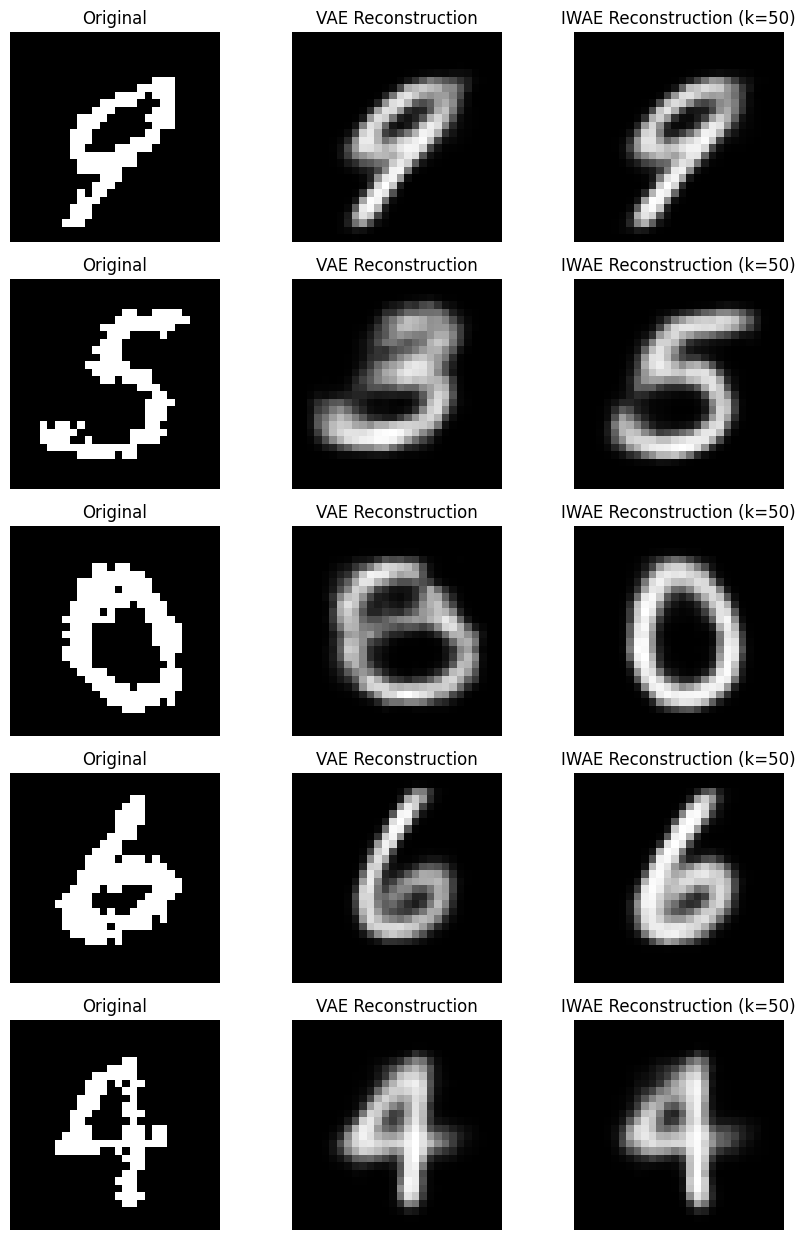

In [40]:
def plot_reconstructions(model, test_ds, num_images=5, k=50):
    batch = next(iter(test_ds))
    images = batch[:num_images]

    fig, axes = plt.subplots(num_images, 3, figsize=(9, 2.5 * num_images))

    for i, x in enumerate(images):
        # p_\theta(x|z), standard VAE
        x = ops.expand_dims(x, axis=0)
        z_mean, z_log_var = model.encoder(x)
        eps = keras.random.normal(shape=(1, 2))
        z = z_mean + ops.exp(0.5 * z_log_var) * eps
        recon_vae = model.decoder(z)  # (1, 28, 28, 1)

        # p_\theta(x|z) using IWAE Sample for q_\phi(z|x)
        z_iwae = sample_z_IWAE(model, x, k=k)
        recon_iwae = model.decoder(z_iwae)  # (1, 28, 28, 1)

        # Plotting
        axes[i, 0].imshow(x[0, ..., 0].detach().cpu(), cmap='gray')
        axes[i, 0].set_title("Original")
        axes[i, 1].imshow(recon_vae[0, ..., 0].detach().cpu(), cmap='gray')
        axes[i, 1].set_title("VAE Reconstruction")
        axes[i, 2].imshow(recon_iwae[0, ..., 0].detach().cpu(), cmap='gray')
        axes[i, 2].set_title(f"IWAE Reconstruction (k={k})")

        for j in range(3):
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

model = get_trained_IWAEDiagonal()
_, _, test_ds = get_datasets(500)
plot_reconstructions(model=model, test_ds=test_ds, num_images=5, k=50)

### Comments

We observe that IWAE sampling improves the output. This is because we are generating $k=50$ decoded images and select the one that is most probable (has the largest weight), based on the log likelihood

#### Question 3 (Total 9 marks)

In this question you will investigate the strength of the learning signal for the models trained with either $\mathcal{L}_{VAE}$ or $\mathcal{L}^k_{IWAE}$. The quantity that you will use to measure this is the signal-to-noise ratio of the gradients used in training. First we define (for the decoder parameters $\theta$):

\begin{align}
\Delta_{VAE}(\theta) &:= \frac{\partial \mathcal{L}_{VAE}(\theta, \phi; x)}{\partial \theta},\\
\Delta^k_{IWAE}(\theta) &:= \frac{\partial \mathcal{L}^k_{IWAE}(\theta, \phi; x)}{\partial \theta},
\end{align}

and similarly for the encoder parameters $\phi$. Then the signal-to-noise ratio is given by

\begin{align}
SNR_{VAE}(\theta) &:= \left| \frac{\mathbb{E}[\Delta_{VAE}(\theta)]}{\sigma[\Delta_{VAE}(\theta)]} \right|,\\[1.5ex]
SNR_{IWAE}(\theta) &:= \left| \frac{\mathbb{E}[\Delta_{IWAE}(\theta)]}{\sigma[\Delta_{IWAE}(\theta)]} \right|,
\end{align}

where $\sigma[\cdot]$ denotes the standard deviation of a random variable. The signal-to-noise ratio is defined similarly for the encoder parameters $\phi$. The expectation and standard deviation in the above definition is with respect to the Monte Carlo samples drawn from the posterior $q_\phi(z\mid x)$ in the definitions of $\mathcal{L}_{VAE}$ and $\mathcal{L}^k_{IWAE}$. For this question you should assume that the encoder parameterises a diagonal Gaussian for the approximate posterior (as in the `VAEDiagonal` and `IWAEDiagonal` classes).

_If you have not been able to successfully implement the `VAEDiagonal` or `IWAEDiagonal` classes in questions 1b) and 2b), you can complete all of question 3 question using the base `VAE` class provided for you, and a trained encoder/decoder as in the week 9 lecture notes._

a) Write a function `compute_snr` that computes estimates for the signal-to-noise ratio for a given list of trainable Variables, and given a single data example. Your function should compute estimates for either $SNR_{VAE}$ or $SNR_{IWAE}$ by estimating the expectation and standard deviation with Monte Carlo samples. Your function should take the following arguments:

* `encoder` and `decoder` network objects. You can assume that the encoder parameterises a diagonal Gaussian for the approximate posterior
* A list of Keras Variable objects (that belong to the encoder or decoder networks)
* An option to compute $SNR_{VAE}$ or $SNR_{IWAE}$
  * If computing $SNR_{IWAE}$, the function will also require $k$ as an argument
* Number of Monte Carlo samples to estimate the expectation and standard deviation in the definition of the $SNR$
* A `data` example that the loss is computed on

The SNR is defined for each parameter. Your function should return a list of SNR values. This list will contain Tensors with the same shape as in the list of trainable Variables input to the function.

_Hint: you may need to add a small value to the computed standard deviation for numerical stability._

**(6 marks)**

In [216]:
def compute_snr(encoder, decoder, variables, model_name, data, num_mc_samples, k=None):
    '''
    Computes the SNR for a single image/data example.
    '''
    eps = 1e-7
    if len(data.shape) == 3:
        data = ops.expand_dims(data, axis=0)
    if data.shape[0] != 1:
        raise ValueError(f'SNR is computed for one image. You provided a batch of {data.shape[0]} images')
    if model_name == 'IWAE' and k is None:
        raise ValueError(f"Parameter 'k' is required for IWAE.")

    z_mean, z_log_var = encoder(data, training=False)
    # print(f'z_mean is a leaf: {z_mean.is_leaf}')
    # z_mean = z_mean.detach()
    # z_log_var = z_log_var.detach()

    gradients_list = [[] for _ in variables]

    # Get underlying torch tensors for evaluating gradient if using torch backend
    torch_params = None
    if keras.config.backend() == 'torch':
        torch_params = [getattr(v, 'value', v) for v in variables]

    for _ in range(num_mc_samples):
        if keras.config.backend() == 'tensorflow':
            with tf.GradientTape() as tape:
                if model_name == 'VAE':
                    epsilon = keras.random.normal(shape=ops.shape(z_mean))
                    z = z_mean + ops.exp(0.5 * z_log_var) * epsilon # 1 sample
                    x_pred = decoder(z, training=False)
                    x_pred = ops.clip(x_pred, eps, 1. - eps)
                    log_p_x_given_z = ops.sum(data * ops.log(x_pred) + (1. - data) * ops.log(1. - x_pred), axis=[1, 2, 3])
                    kl_div = -0.5 * ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=-1)
                    loss = ops.mean(log_p_x_given_z - kl_div)  # ELBO estimate

                elif model_name == 'IWAE':
                    epsilon = keras.random.normal(shape=(k,) + ops.shape(z_mean)[1:])
                    z = z_mean + ops.exp(0.5 * z_log_var) * epsilon # k samples
                    x_pred = decoder(z, training=False)
                    x_pred = ops.clip(x_pred, eps, 1. - eps)
                    log_p_x_z = ops.sum(ops.expand_dims(data, 0) * ops.log(x_pred) + (1. - ops.expand_dims(data, 0)) * ops.log(1. - x_pred), axis=[1, 2, 3])
                    log_p_z = -0.5 * ops.sum(ops.square(z) + ops.log(2 * np.pi), axis=-1)
                    log_q_z_x = -0.5 * ops.sum(ops.square(z - z_mean) * ops.exp(-z_log_var) + z_log_var + ops.log(2 * np.pi), axis=-1)
                    log_weights = log_p_x_z + log_p_z - log_q_z_x
                    # Gradient is of L_k = logsumexp(log_wi) - log(k)
                    loss = ops.mean(ops.logsumexp(log_weights, axis=0) - ops.log(float(k)))
                else:
                    raise ValueError(f'Invalid model name: {model_name}')
            grads = tape.gradient(loss, variables)

        else:
            if model_name == 'VAE':
                epsilon = keras.random.normal(shape=ops.shape(z_mean))
                z = z_mean + ops.exp(0.5 * z_log_var) * epsilon
                x_pred = decoder(z, training=False)
                x_pred = ops.clip(x_pred, eps, 1. - eps)
                log_p_x_given_z = ops.sum(data * ops.log(x_pred) + (1. - data) * ops.log(1. - x_pred), axis=[1, 2, 3])
                kl_div = -0.5 * ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=-1)
                loss = ops.mean(log_p_x_given_z - kl_div)  # ELBO estimate

            elif model_name == 'IWAE':
                epsilon = keras.random.normal(shape=(k,) + ops.shape(z_mean)[1:])
                z = z_mean + ops.exp(0.5 * z_log_var) * epsilon  # k samples
                x_pred = decoder(z, training=False)
                x_pred = ops.clip(x_pred, eps, 1. - eps)
                log_p_x_z = ops.sum(
                    ops.expand_dims(data, 0) * ops.log(x_pred) + (1. - ops.expand_dims(data, 0)) * ops.log(1. - x_pred),
                    axis=[1, 2, 3])
                log_p_z = -0.5 * ops.sum(ops.square(z) + ops.log(2 * np.pi), axis=-1)
                log_q_z_x = -0.5 * ops.sum(
                    ops.square(z - z_mean) * ops.exp(-z_log_var) + z_log_var + ops.log(2 * np.pi), axis=-1)
                log_weights = log_p_x_z + log_p_z - log_q_z_x
                # Gradient is of L_k = logsumexp(log_wi) - log(k)
                loss = ops.mean(ops.logsumexp(log_weights, axis=0) - ops.log(float(k)))
            else:
                raise ValueError(f'Invalid model name: {model_name}')

            # Use autograd.grad - ensures correct graph handling per sample
            grads = list(torch.autograd.grad(
                outputs=loss,
                inputs=torch_params,  # Use pre-extracted torch tensors
                retain_graph=True,  # if set to false, it throws an error the second time the gradient is computed - investigating
                create_graph=False,
                allow_unused=True
            ))

        # Store gradients (handle None values)
        for i, g in enumerate(grads):
            if g is not None:
                # Detach/clone/move to cpu in case this is what is causing the graph issue
                gradients_list[i].append(g.detach().cpu())
            else:
                # Append zeros manually if grad is None
                param_value = getattr(variables[i], 'value', variables[i])
                zero_grad_tensor = ops.zeros_like(param_value).detach().cpu()
                gradients_list[i].append(zero_grad_tensor)

    # Compute Mean, Std Dev, and SNR for each variable
    snr_list = []
    for i, var_grads_list in enumerate(gradients_list):
        valid_var_grads = [g for g in var_grads_list if g is not None]
        if not valid_var_grads:
            print('AAAAAAAA')
            param_value = getattr(variables[i], 'value', variables[i])
            snr_list.append(ops.zeros_like(ops.convert_to_tensor(param_value)))
            continue

        stacked_grads = ops.stack(valid_var_grads, axis=0)
        mean_grad = ops.mean(stacked_grads, axis=0)
        variance_grad = ops.mean(ops.square(stacked_grads - mean_grad), axis=0)
        std_dev_grad = ops.sqrt(variance_grad)
        snr = ops.abs(mean_grad / (std_dev_grad + eps))
        snr_list.append(snr)
    return snr_list

In [217]:
vae_model = get_trained_VAEDiagonal()
iwae_model = get_trained_IWAEDiagonal()

vae_vars = vae_model.trainable_variables
iwae_vars = iwae_model.trainable_variables
x = next(iter(train_ds))[0, ...]
vae_snr = compute_snr(encoder=vae_model.encoder, decoder=vae_model.decoder, model_name='VAE',
                      data=x, num_mc_samples=20, variables=vae_vars)
iwae_snr = compute_snr(encoder=iwae_model.encoder, decoder=iwae_model.decoder, model_name='VAE',
                      data=x, num_mc_samples=20, variables=iwae_vars)


In [218]:
print(iwae_snr[0].mean())
print(vae_snr[0].mean())
print(len(vae_vars))
print(len(iwae_vars))

tensor(0.0938, device='mps:0')
tensor(0.6413, device='mps:0')
34
34


b) Using your `compute_snr` function from part a), compute $SNR_{VAE}$ and $SNR_{IWAE}$ (with $k=50$) for the encoder trainable variables $\phi$, and for the decoder trainable variables $\theta$. The SNR values should be averaged over a batch of data drawn from the training Dataset.

Display histogram plots (one for $\phi$ and one for $\theta$) showing the distribution of SNR values under the $\mathcal{L}_{VAE}$ loss and $\mathcal{L}_{IWAE}^{50}$ loss.

**(3 marks)**

In [219]:
def compute_snr_for_batch(encoder, decoder, variables, model_name, data_batch, num_mc_samples, k=None):
    '''
    Helper function - computes SNR for a batch of images by calling compute_snr
    '''
    sum_snr_list = [ops.zeros_like(ops.convert_to_tensor(getattr(v, 'value', v))) for v in variables]
    count = 0

    for i in range(batch_size):
        data_example = ops.expand_dims(ops.convert_to_tensor(data_batch[i]), axis=0)
        single_snr_list = compute_snr(encoder=encoder, decoder=decoder, variables=variables, model_name=model_name, data=data_example,
                                      num_mc_samples=num_mc_samples, k=k)
        for j, snr_val in enumerate(single_snr_list):
            sum_snr_list[j] = sum_snr_list[j] + snr_val
        count += 1

    if count > 0:
        avg_snr_list = [total_snr / float(count) for total_snr in sum_snr_list]
    else:
        avg_snr_list = sum_snr_list

    return avg_snr_list


In [225]:
# Setup inputs
k = 50
mc_samples = 50
batch_size = 500

f = lambda model_name, encoder, decoder, variables: compute_snr_for_batch(
    encoder=encoder, decoder=decoder, data_batch=data, variables=variables, num_mc_samples=mc_samples, k=k, model_name=model_name
)

encoder_snr = dict()
decoder_snr = dict()
train_ds, _, _ = get_datasets(batch_size)
data = next(iter(train_ds))

In [226]:
# VAEDiagonal
model_name = 'VAE'
encoder_snr[model_name] = f(model_name=model_name, encoder=vae_model.encoder, decoder=vae_model.decoder, variables=vae_model.encoder.trainable_variables)
decoder_snr[model_name] = f(model_name=model_name, encoder=vae_model.encoder, decoder=vae_model.decoder, variables=vae_model.decoder.trainable_variables)


In [ ]:
# VAEDiagonal
model_name = 'IWAE'
encoder_snr[model_name] = f(model_name=model_name, encoder=iwae_model.encoder, decoder=iwae_model.decoder,
                            variables=iwae_model.encoder.trainable_variables)
decoder_snr[model_name] = f(model_name=model_name, encoder=iwae_model.encoder, decoder=iwae_model.decoder,
                            variables=iwae_model.decoder.trainable_variables)

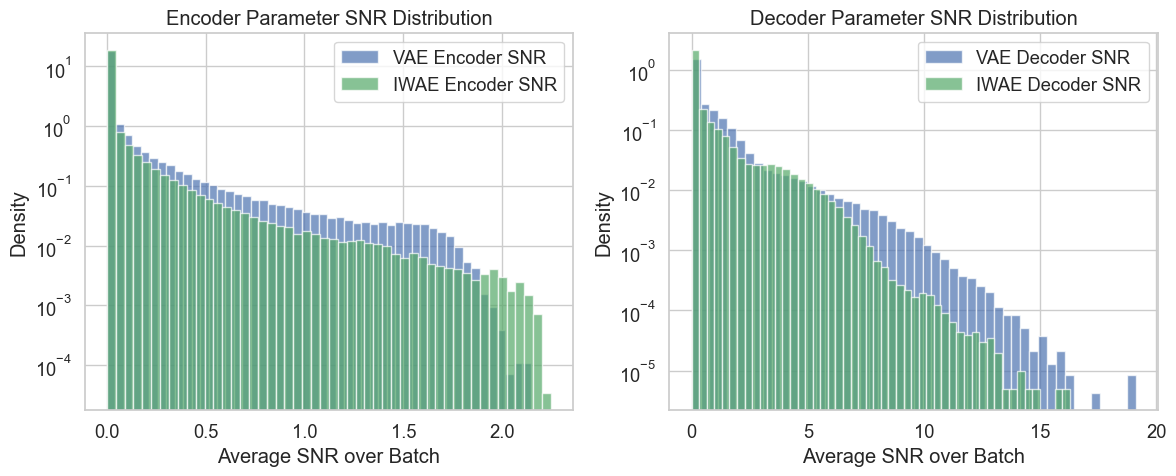

Plotting complete.


In [224]:
def flatten_snr_list(snr_list):
    flat_values = []
    for snr_tensor in snr_list:
        # Convert tensor to numpy and flatten
        flat_values.append(np.array(snr_tensor.detach().cpu()).flatten())
    return np.concatenate(flat_values)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k, v in encoder_snr.items():
    axes[0].hist(flatten_snr_list(v), bins=50, alpha=0.7, label=f'{k} Encoder SNR', density=True)
    axes[0].set_title('Encoder Parameter SNR Distribution')
    axes[0].set_xlabel('Average SNR over Batch')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    axes[0].set_yscale('log')  # SNRs vary widely

for k, v in decoder_snr.items():
    axes[1].hist(flatten_snr_list(v), bins=50, alpha=0.7, label=f'{k} Decoder SNR', density=True)
    axes[1].set_title('Decoder Parameter SNR Distribution')
    axes[1].set_xlabel('Average SNR over Batch')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].set_yscale('log')  # Use log scale if SNRs vary widely

plt.tight_layout()
plt.show()
print("Plotting complete.")

#### Question 4 (Total 10 marks)

Provide a separate PDF report with an account of the experiments you have run in this assessment. Your report should include details of the results from all experiments, your choice of architecture for the encoder and decoder networks, and any other choices you have made throughout the development of the models. If you encountered difficulties to successfully train the model(s) you should report these, and if possible suggest what you think might be potential reasons for these difficulties.

Your report should also include your interpretation and analysis of the results, and what you think they might suggest about training inference and generative networks on the binarised MNIST dataset using the VAE or IWAE training objective.

Marks will be awarded for presentation and clarity. Your report should be no more than 2 pages, excluding any references and figures (which can be included in an appendix).

**(10 marks)**